<!-- banner-smart-reactor -->
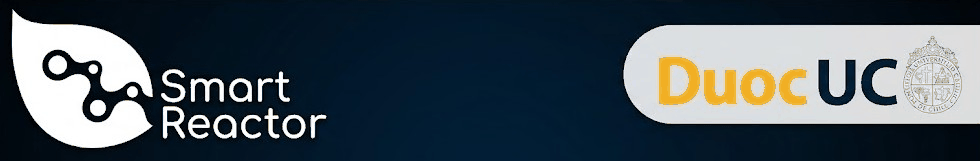

# Capstone: 

# Cliente:  Smart Reactor




# 1. Entendimiento del Negocio

## Contexto

Smart Reactor es una startup que se encarga de tratar residuos orgánicos a traves de maquinaria que lo procesa , la empresa desea realizar un estudio del tratamiento de residuos organicos que realizan las otras empresas en chile.

A partir de lo anterior buscamos una base de datos que contenga nombre de la empresa , desechos orgánicos y tratamiento de los mismos,
empezando la búsqueda por el sitio de bases de datos Abierta del gobierno de chile.


# Análisis de Residuos Industriales - Base de datos SINADER

**Dataset:** Declaraciones de residuos industriales del Sistema Nacional de Declaración de Residuos (SINADER) de Chile.

**Años disponibles:** 2014, 2015, 2016, 2017, 2019, 2020, 2021,2022 y 2023

**Objetivos del notebook:**
El proyecto se centra en la minería y extracción de datos sobre la generación y tratamiento de residuos orgánicos en el sector comercial, con énfasis en restaurantes. El objetivo es identificar patrones de desperdicio que permitan implementar estrategias de economía circular, optimizando la reutilización de recursos, reduciendo la huella ambiental y mejorando la eficiencia operativa de los negocios.

SINADER (Sistema Nacional de Declaración de Residuos) es el sistema chileno mediante el cual los generadores industriales declaran sus residuos. Cada declaración incluye:

- **Generador:** empresa, establecimiento, ubicación
- **Residuo:** tipo (LER), cantidad en toneladas
- **Tratamiento:** destino final del residuo (eliminación, valorización, etc.)

## Relevancia del problema

- **Clasificación de residuos orgánicos:** Identificar qué residuos son orgánicos permite orientar políticas de reciclaje, compostaje y valorización.
- **Predicción del tratamiento:** Anticipar qué tratamiento recibirá un residuo ayuda a planificar infraestructura de gestión.
- **Importación de conocimiento:** Los patrones de generación y tratamiento pueden transferirse a otros países con sistemas similares.

## Variables clave del negocio

| Variable | Descripción |
|----------|-------------|
| `cantidad_toneladas` | Volumen de residuo declarado |
| `tratamiento_n1_name` | Tipo de tratamiento (Eliminación / Valorización / Recepción y Almacenamiento) |
| `tratamiento_n2_name` | Subtipo de tratamiento (Reciclaje, Disposición final, etc.) |
| `ler_capitulo` | Categoría del residuo según LER |
| `region` | Ubicación geográfica del generador |
| `rubro` | Sector industrial del generador |

## Preguntas de negocio

1. ¿Qué características determinan que un residuo sea orgánico?
2. ¿Podemos predecir el tipo de tratamiento que recibirá un residuo?
3. ¿Existen patrones temporales o geográficos en la gestión de residuos?

# 2. Entendimiento de los Datos

## 2.1 Carga y Unificación de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Busca la carpeta data/ desde el directorio actual hacia arriba, para que la celda
# funcione tanto si el kernel arranca en notebook/ como en la raiz del proyecto.
DATA_DIR = next(
    (p / 'data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data').is_dir()),
    None
)
if DATA_DIR is None:
    raise FileNotFoundError(f'No se encontro la carpeta data/ partiendo de {Path.cwd()}')

files = sorted(DATA_DIR.glob('gi-sinader-*-ckan*.csv'))
print(f'Carpeta de datos: {DATA_DIR}')
print(f'Archivos encontrados: {len(files)}')
for f in files:
    print(f'  -> {f.name}')

if not files:
    raise FileNotFoundError(f'No hay CSV que calcen con el patron en {DATA_DIR}')

dfs = []
for f in files:
    try:
        df = pd.read_csv(
            f,
            sep=';',
            encoding='latin1',
            on_bad_lines='skip',
            engine='python'
        )
        dfs.append(df)
        print(f'OK: {f.name} -> {df.shape[0]:,} filas, {df.shape[1]} columnas')
    except Exception as e:
        print(f'ERROR en {f.name}: {e}')

if not dfs:
    raise RuntimeError('No se pudo cargar ningun archivo.')

df = pd.concat(dfs, ignore_index=True)
print(f'\nShape total: {df.shape}')
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

anios = sorted(df['año'].dropna().unique().astype(int).tolist())
print(f'Anios cargados: {anios[0]}-{anios[-1]} ({len(anios)} anios)')
faltantes = [a for a in range(anios[0], anios[-1] + 1) if a not in anios]
if faltantes:
    print(f'AVISO - anios sin datos en data/: {faltantes}')

## 2.2 Vista General de los Datos

In [2]:
display(df.head())
display(df.info())

,año,mes,id_vu,razon_social,rut_razon_social,nombre_establecimiento,rubro,rubro_id,ciiu4,ciiu4_id,...,ler_numero_capitulo,ler_subcapitulo,ler_numero_subcapitulo,trazabilidad__id_vu,trazabilidad__nombre_establecimiento,trazabilidad__razon_social,trazabilidad__comuna,trazabilidad__region,trazabilidad__pais,"aÃ±o,mes,id_vu,razon_social,rut_razon_social,nombre_establecimiento,rubro,rubro_id,ciiu4,ciiu4_id,ciiu6,ciiu6_id,region,provincia,comuna,codigo_unico_territorial,latitud,longitud,rol_establecimiento,declaracion_id,tipo_recepcion,cantidad_toneladas,tratamiento_n1_id,tratamiento_n1_name,tratamiento_n2_id,tratamiento_n2_name,tratamiento_n3_id,tratamiento_n3_name,LER,LER_numero,LER_capitulo,LER_numero_capitulo,LER_subcapitulo,LER_numero_subcapitulo,trazabilidad__id_vu,trazabilidad__nombre_establecimiento,trazabilidad__razon_social,trazabilidad__comuna,trazabilidad__region,trazabilidad__pais"
0,2014.0,0.0,4588.0,CIA CONTRACTUAL MINERA OJOS DEL SALADO,96635170-5,PLANTA PEDRO AGUIRRE CERDA,Minería,NaN,Extracción y procesamiento de cobre,B0400,...,20.0,Fracciones recogidas selectivamente (excepto l...,1.0,4989.0,PLANTA COLINA,GERDAU AZA S A,Renca,Metropolitana de Santiago,Chile,NaN
1,2014.0,0.0,4302260.0,UNILEVER CHILE SCC LIMITADA,92091000-9,UNILEVER CHILE SA PLANTA PANAMERICANA NORTE,Otras industrias manufactureras,NaN,Elaboración de comidas y platos preparados,C1075,...,15.0,Envases (incluidos los residuos de envases de ...,1.0,5459117.0,SOREPA,SOC RECUPERADORA DE PAPEL S A,San Joaquín,Metropolitana de Santiago,Chile,NaN
2,2014.0,0.0,796.0,FRIGORIFICO DE OSORNO S A,96518090-7,FRIGORIFICO DE OSORNO S.A,Otras industrias manufactureras,NaN,Elaboración y conservación de carne,C1010,...,2.0,Residuos de la preparación y elaboración de ca...,2.0,NaN,NaN,VERTEDERO MUNICIPAL DE CURACO DE LA COMUNA DE ...,NaN,NaN,NaN,NaN
3,2014.0,0.0,5452075.0,COPEFRUT S A,81836000-2,PLANTA BUIN,Otras industrias manufactureras,NaN,"Elaboración y conservación de frutas, legumbre...",C1030,...,2.0,Residuos de la preparación y elaboración de fr...,3.0,78709.0,RELLENO SANITARIO SANTIAGO PONIENTE,VEOLIA SU CHILE SA,Las Condes,Metropolitana de Santiago,Chile,NaN
4,2014.0,0.0,1505.0,COCA COLA DE CHILE S A,96714870-9,COCA COLA DE CHILE SA,Otras industrias manufactureras,NaN,Elaboración de bebidas no alcohólicas; producc...,C1104,...,2.0,Residuos de la producción de bebidas alcohólic...,7.0,5461360.0,ECOLOGICA SA,ECO LOGICA S A,Lampa,Metropolitana de Santiago,Chile,NaN


<class 'pandas.DataFrame'>
RangeIndex: 520345 entries, 0 to 520344
Data columns (total 42 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Non-Null Count   Dtype  
---  ------                                                                                                                                                                                                                                                                        

None

In [3]:
# Estadísticas descriptivas
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
año,367722.0,NaN,NaN,NaN,2018.823318,2.49817,2014.0,2017.0,2018.0,2021.0,2023.0
mes,367722.0,NaN,NaN,NaN,1.681629,3.348159,0.0,0.0,0.0,1.0,12.0
id_vu,367722.0,NaN,NaN,NaN,3559917.02265,2431709.393442,6.0,320029.0,5441757.0,5464643.0,5496615.0
razon_social,367587,5519,CENCOSUD RETAIL S.A.,13719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rut_razon_social,367722,4948,88680500-4,13756,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_establecimiento,367687,13908,SCA CHILE SA,7453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rubro,366600,19,Otras industrias manufactureras,86610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rubro_id,18336.0,NaN,NaN,NaN,12.398669,6.355909,1.0,5.0,10.0,20.0,20.0
ciiu4,366600,305,Venta al por menor en comercios no especializa...,32182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ciiu4_id,366461,304,G4711,32182,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.3 Análisis de Valores Nulos

Columnas con valores nulos:


,Nulos,Porcentaje (%)
tipo_recepcion,520345,100.00
declaracion_id,520345,100.00
rubro_id,502009,96.48
"aÃ±o,mes,id_vu,razon_social,rut_razon_social,nombre_establecimiento,rubro,rubro_id,ciiu4,ciiu4_id,ciiu6,ciiu6_id,region,provincia,comuna,codigo_unico_territorial,latitud,longitud,rol_establecimiento,declaracion_id,tipo_recepcion,cantidad_toneladas,tratamiento_n1_id,tratamiento_n1_name,tratamiento_n2_id,tratamiento_n2_name,tratamiento_n3_id,tratamiento_n3_name,LER,LER_numero,LER_capitulo,LER_numero_capitulo,LER_subcapitulo,LER_numero_subcapitulo,trazabilidad__id_vu,trazabilidad__nombre_establecimiento,trazabilidad__razon_social,trazabilidad__comuna,trazabilidad__region,trazabilidad__pais",367722,70.67
trazabilidad__id_vu,280239,53.86
trazabilidad__comuna,272917,52.45
trazabilidad__region,272917,52.45
trazabilidad__pais,272917,52.45
trazabilidad__nombre_establecimiento,271556,52.19
trazabilidad__razon_social,255259,49.06


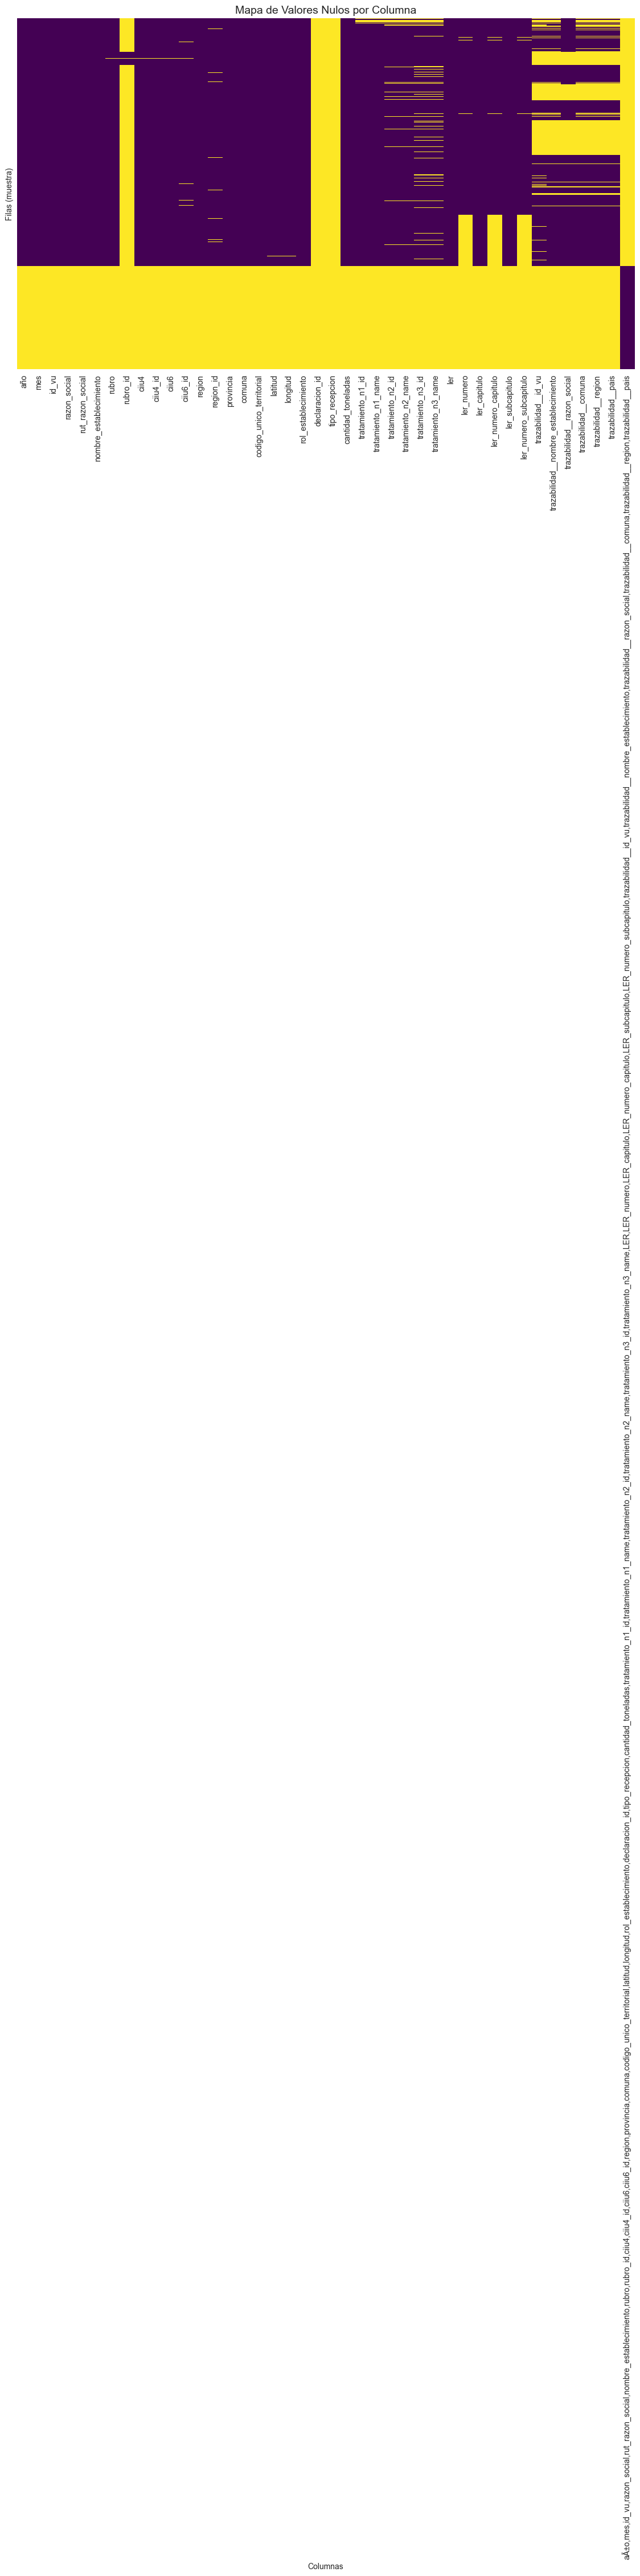

In [4]:
# Visualización de nulos
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, 'Porcentaje (%)': null_pct})
null_df = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
print('Columnas con valores nulos:')
display(null_df)

# Heatmap de nulos
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=ax)
ax.set_title('Mapa de Valores Nulos por Columna', fontsize=14)
ax.set_xlabel('Columnas')
ax.set_ylabel('Filas (muestra)')
plt.tight_layout()
plt.show()

Si bien los nulos en "rubro ID" son casi absolutos , como el propósito diferenciador se puede conservar apreciando que existen diversos nobres de rubros , lo mas aceptable seria utilizar un label encoder en los nulos (agrupando los que son del mismo rubro)

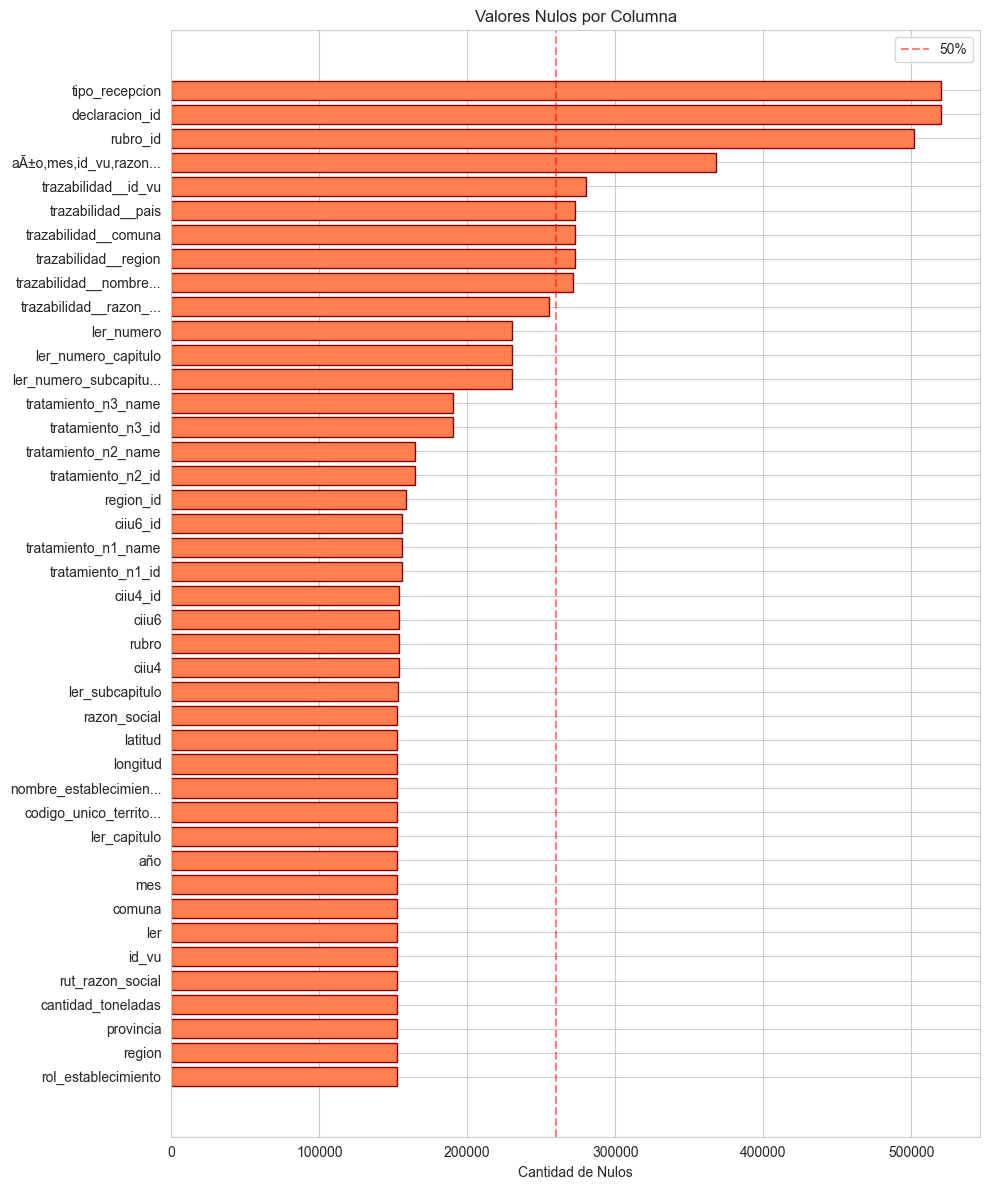

In [5]:
# Barras de nulos por columna con etiquetas cortas
null_sorted = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(range(len(null_sorted)), null_sorted['Nulos'].values, color='coral', edgecolor='darkred')

# Acortar etiquetas a máximo 20 caracteres
labels = [col[:20] + ('...' if len(col) > 20 else '') for col in null_sorted.index]

ax.set_yticks(range(len(null_sorted)))
ax.set_yticklabels(labels)

ax.set_xlabel('Cantidad de Nulos')
ax.set_title('Valores Nulos por Columna')
ax.axvline(x=len(df)*0.5, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()


## 2.4 Análisis de Outliers - Variable `cantidad_toneladas`

Estadísticas de cantidad_toneladas:


count    367722.000000
mean        264.057869
std        3901.733281
min           0.000000
1%            0.010500
5%            0.110000
25%           1.250000
50%           5.750000
75%          32.139500
90%         166.200000
95%         439.939050
99%        3938.865000
max      749839.990000
Name: cantidad_toneladas_num, dtype: float64

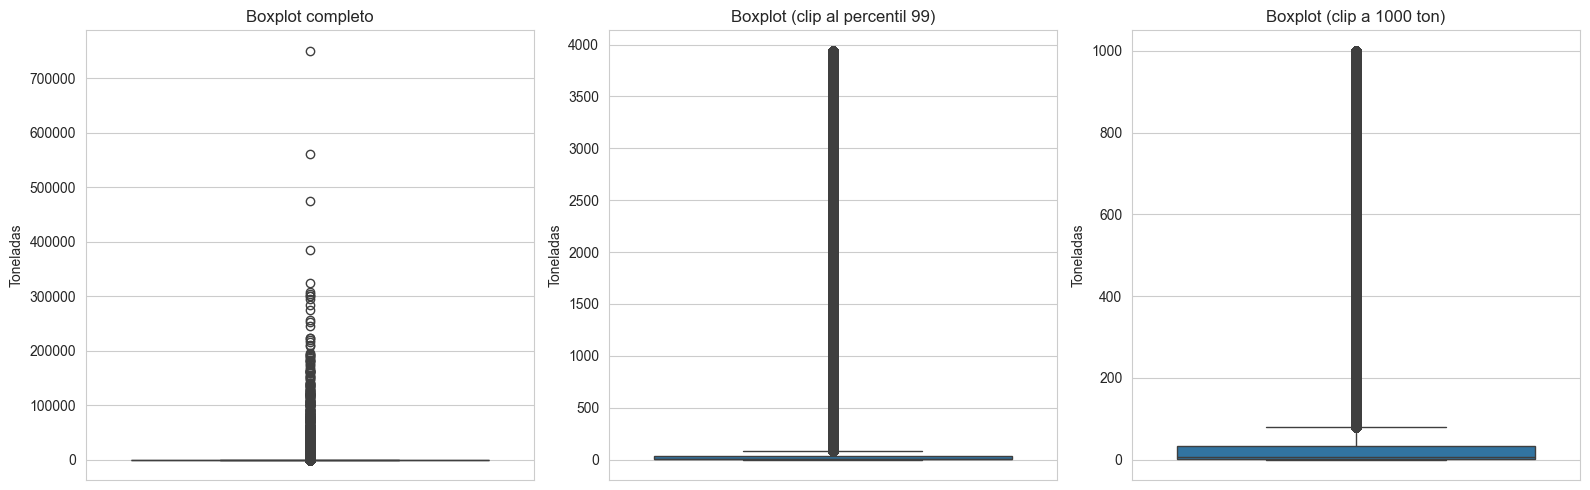

In [6]:
# La variable cantidad_toneladas viene como string con coma decimal
# Limpieza básica para visualización
df['cantidad_toneladas_num'] = (
    df['cantidad_toneladas']
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9\.\-]', '', regex=True)
)
df['cantidad_toneladas_num'] = pd.to_numeric(df['cantidad_toneladas_num'], errors='coerce')

print('Estadísticas de cantidad_toneladas:')
display(df['cantidad_toneladas_num'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Boxplot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(y=df['cantidad_toneladas_num'], ax=axes[0])
axes[0].set_title('Boxplot completo')
axes[0].set_ylabel('Toneladas')

sns.boxplot(y=df['cantidad_toneladas_num'].clip(upper=df['cantidad_toneladas_num'].quantile(0.99)), ax=axes[1])
axes[1].set_title('Boxplot (clip al percentil 99)')
axes[1].set_ylabel('Toneladas')

sns.boxplot(y=df['cantidad_toneladas_num'].clip(upper=1000), ax=axes[2])
axes[2].set_title('Boxplot (clip a 1000 ton)')
axes[2].set_ylabel('Toneladas')

plt.tight_layout()
plt.show()

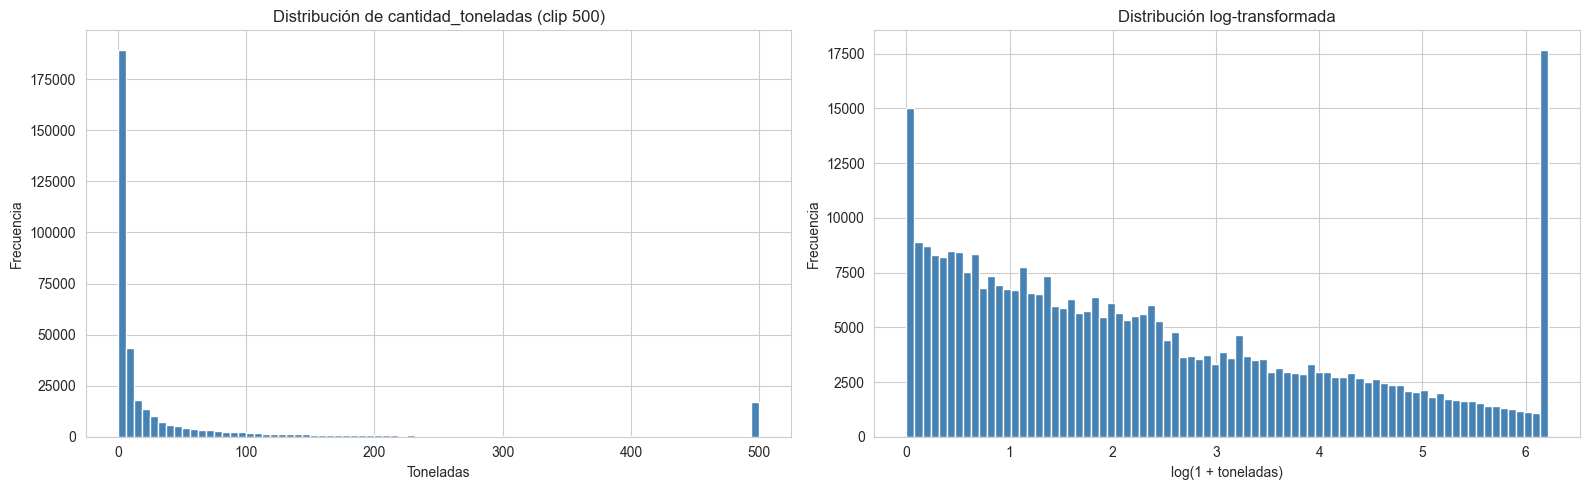

In [7]:
# Histograma de cantidad_toneladas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(df['cantidad_toneladas_num'].clip(upper=500), bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Toneladas')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de cantidad_toneladas (clip 500)')

axes[1].hist(np.log1p(df['cantidad_toneladas_num'].clip(upper=500)), bins=80, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log(1 + toneladas)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución log-transformada')
plt.tight_layout()
plt.show()

## 2.5 Análisis Univariado de Variables Categóricas

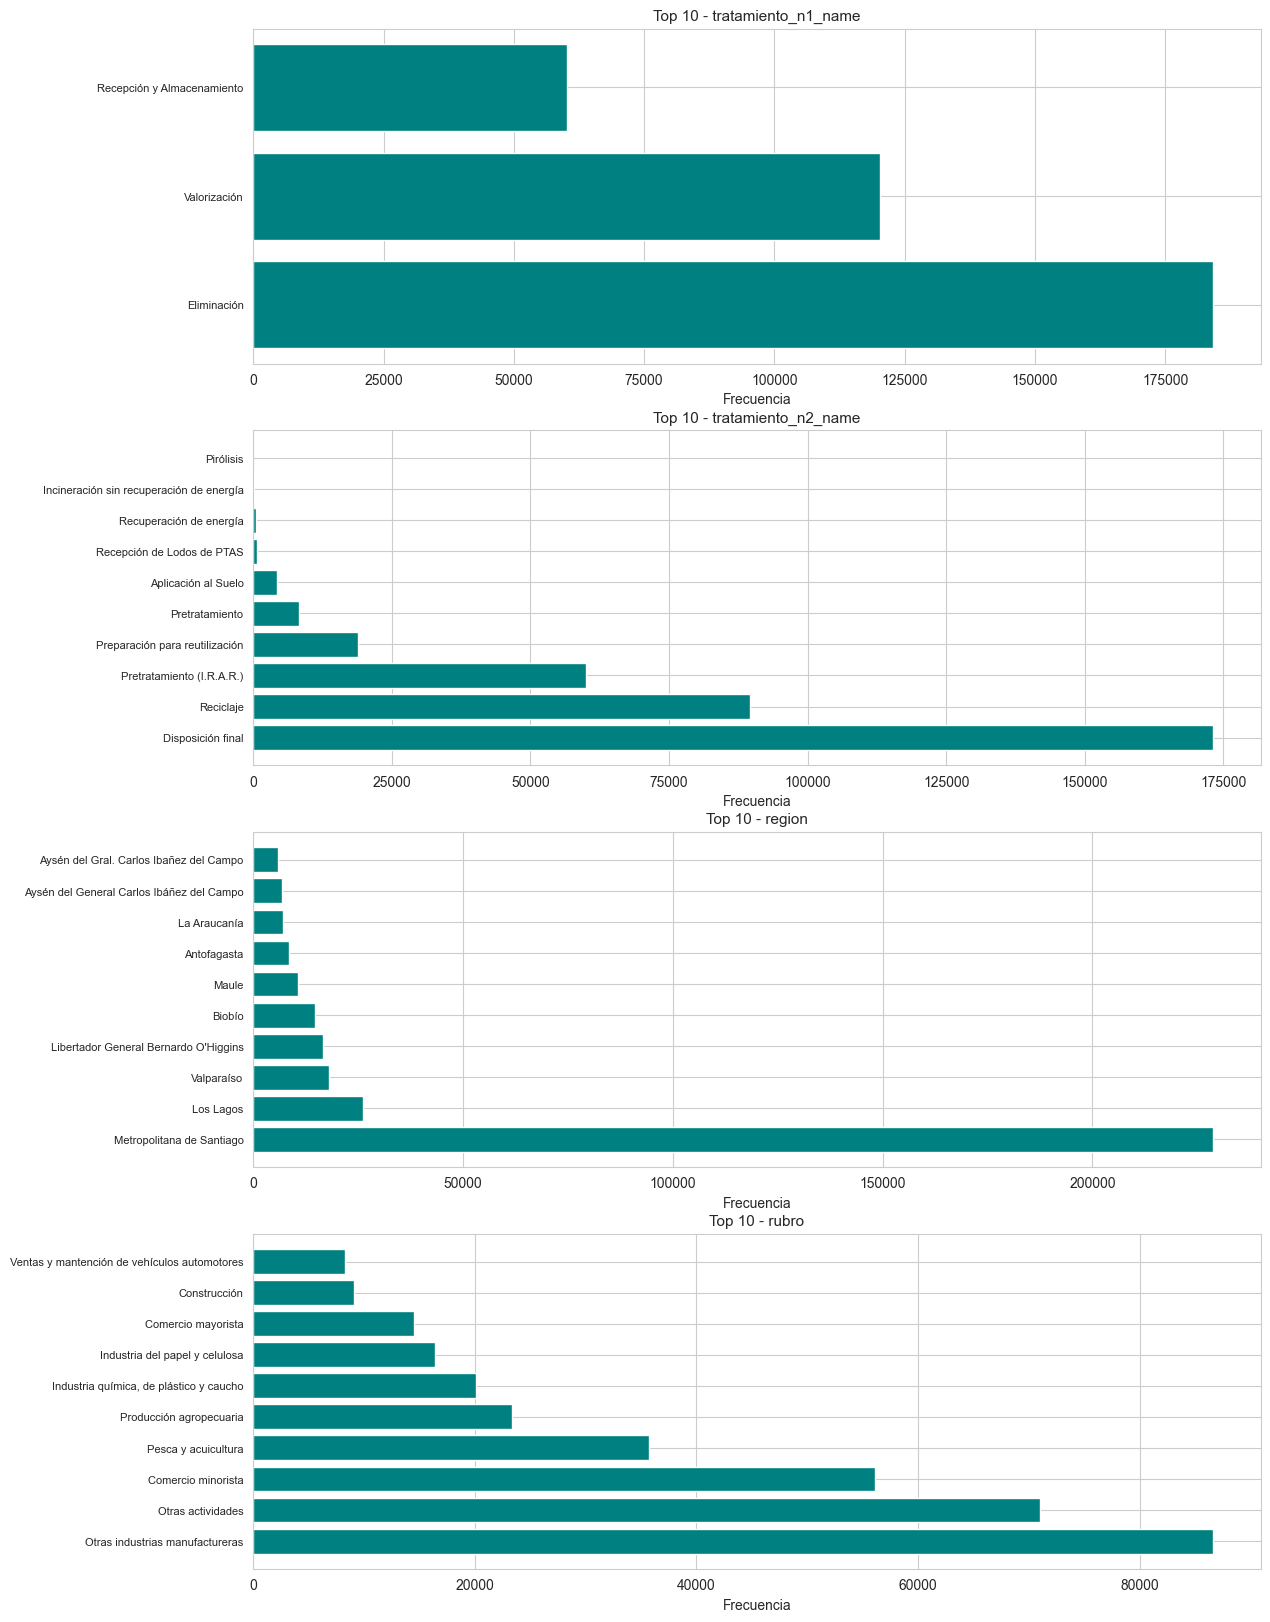

In [8]:
# Variables categóricas principales
try:
 cat_cols = ['tratamiento_n1_name', 'tratamiento_n2_name', 'region', 'rubro', 'ler_capitulo']

 fig, axes = plt.subplots(4, 1, figsize=(13, 20))
 axes = axes.flatten()
 for i, col in enumerate(cat_cols):
     if col in df.columns:
         top10 = df[col].value_counts().head(10)
         axes[i].barh(range(len(top10)), top10.values, color='teal', edgecolor='white')
         axes[i].set_yticks(range(len(top10)))
         axes[i].set_yticklabels(top10.index, fontsize=8)
         axes[i].set_xlabel('Frecuencia')
         axes[i].set_title(f'Top 10 - {col}', fontsize=11)
 axes[-1].axis('off')

 plt.tight_layout()
 plt.show()
except IndexError:
    pass

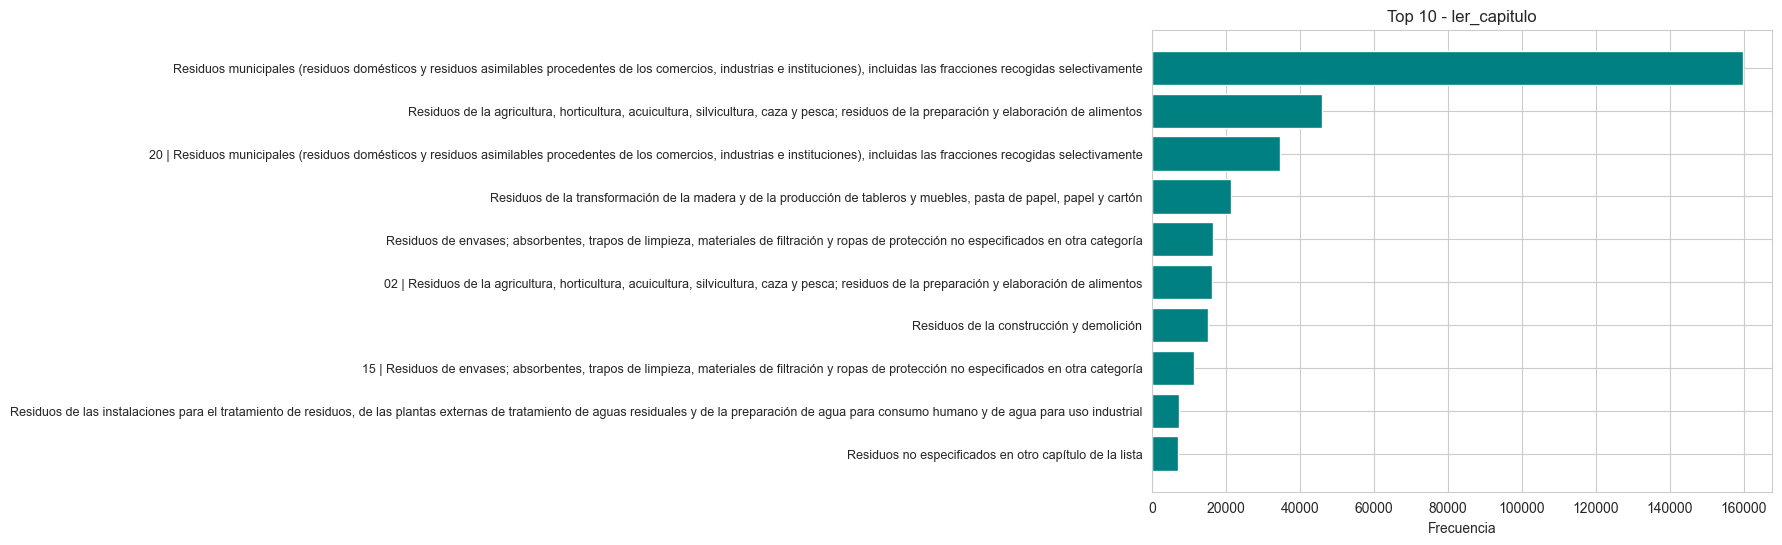

In [9]:
col = 'ler_capitulo'

if col in df.columns:
    top10 = df[col].value_counts().head(10)
    plt.figure(figsize=(8, 6))
    plt.barh(range(len(top10)), top10.values, color='teal', edgecolor='white')
    plt.yticks(range(len(top10)), top10.index, fontsize=9)
    plt.gca().invert_yaxis()  # más frecuente arriba
    plt.xlabel('Frecuencia')
    plt.title(f'Top 10 - {col}', fontsize=12)
    plt.tight_layout()
    plt.show()

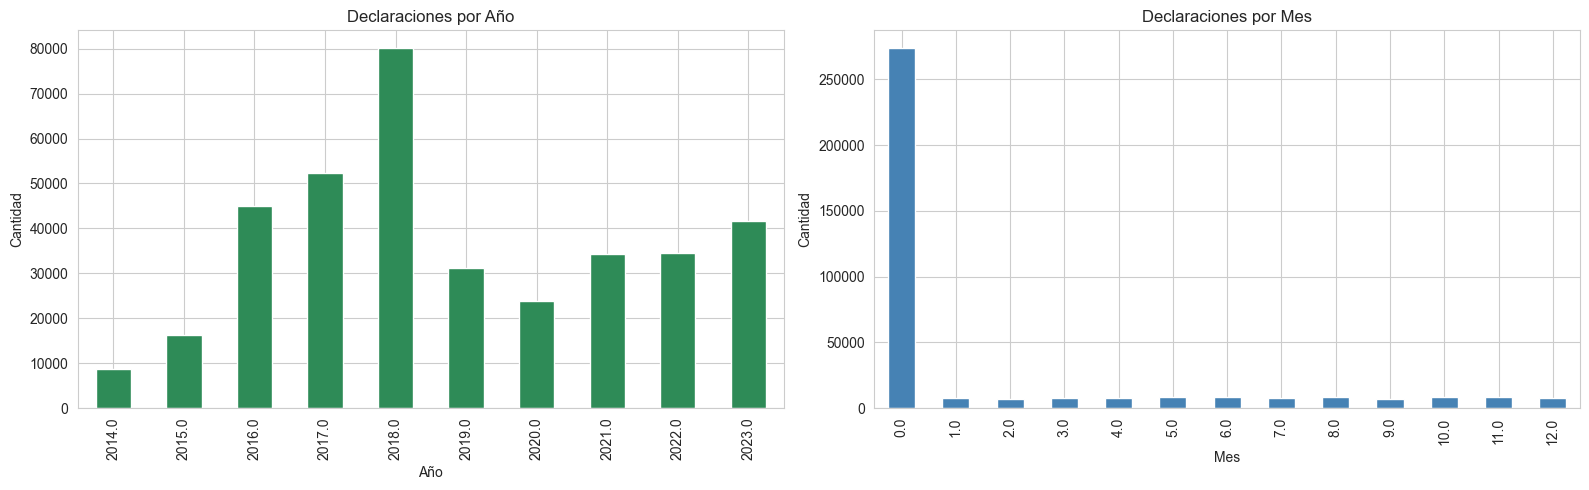

In [10]:
# Distribución temporal
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df['año'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='seagreen', edgecolor='white')
axes[0].set_title('Declaraciones por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')

df['mes'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Declaraciones por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

## 2.6 Análisis Bivariado - Cruces de Variables

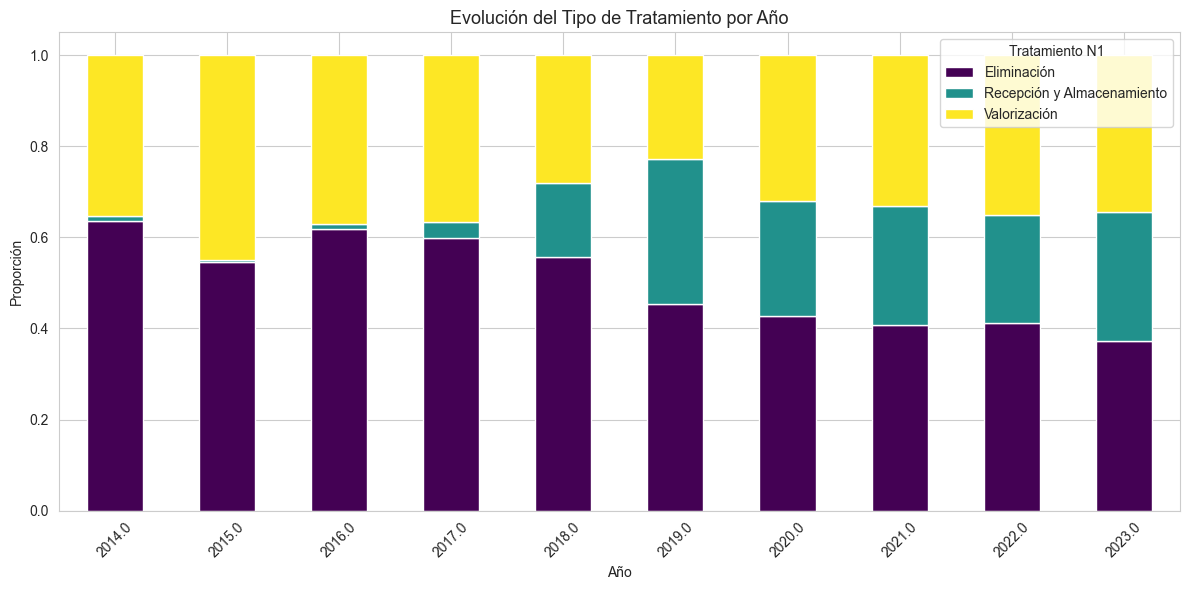

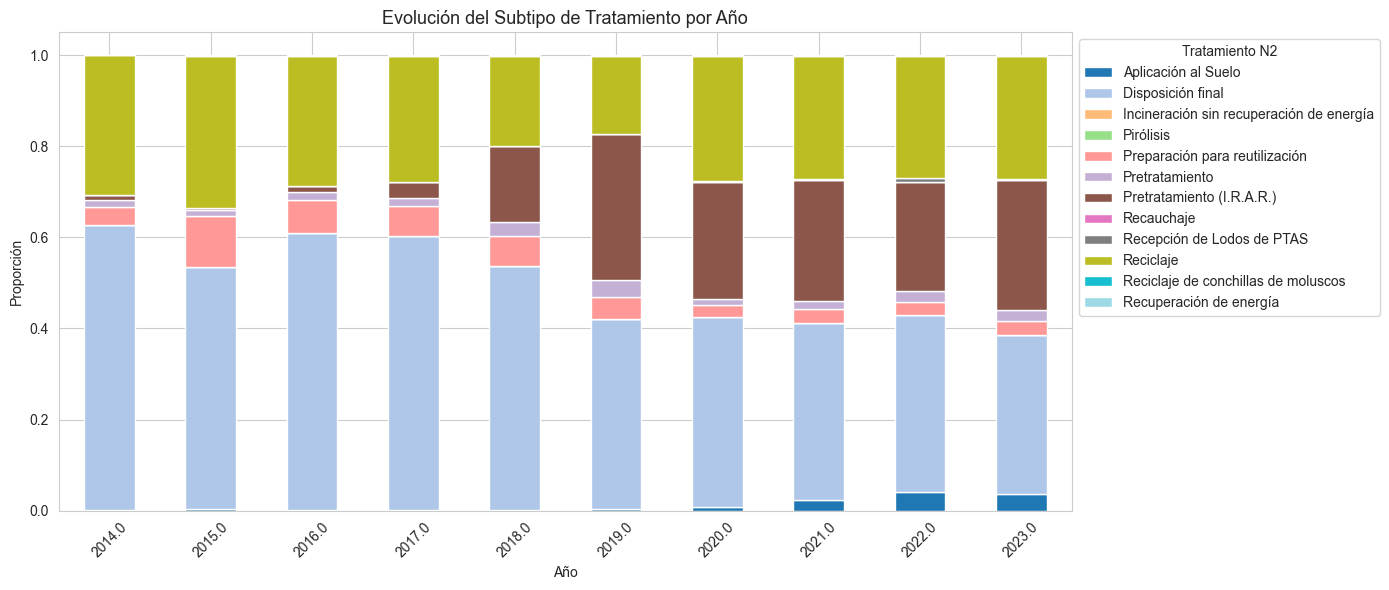

In [11]:
# 1. Tratamiento_n1 vs Año
ct1 = pd.crosstab(df['año'], df['tratamiento_n1_name'], normalize='index')
fig, ax = plt.subplots(figsize=(12, 6))
ct1.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='white')
ax.set_title('Evolución del Tipo de Tratamiento por Año', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Proporción')
ax.legend(title='Tratamiento N1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Tratamiento_n2 vs Año
ct2 = pd.crosstab(df['año'], df['tratamiento_n2_name'], normalize='index')
fig, ax = plt.subplots(figsize=(14, 6))
ct2.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='white')
ax.set_title('Evolución del Subtipo de Tratamiento por Año', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Proporción')
ax.legend(title='Tratamiento N2', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

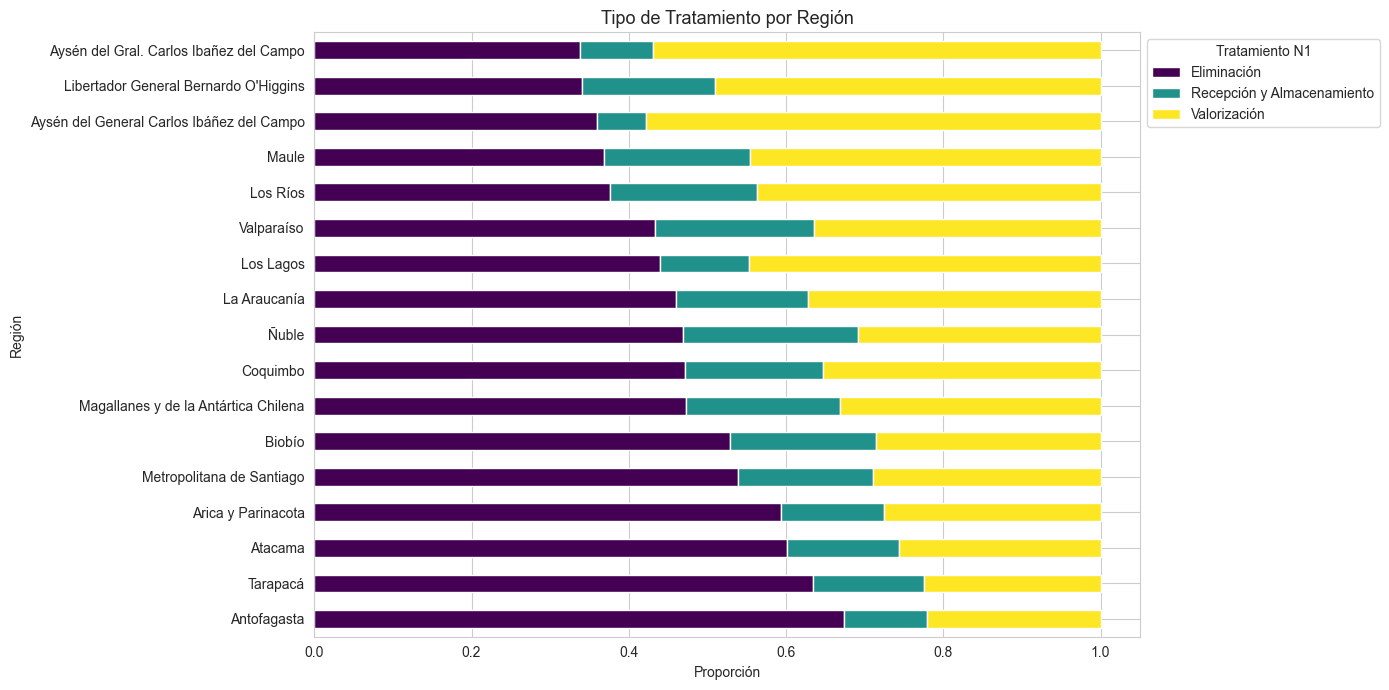

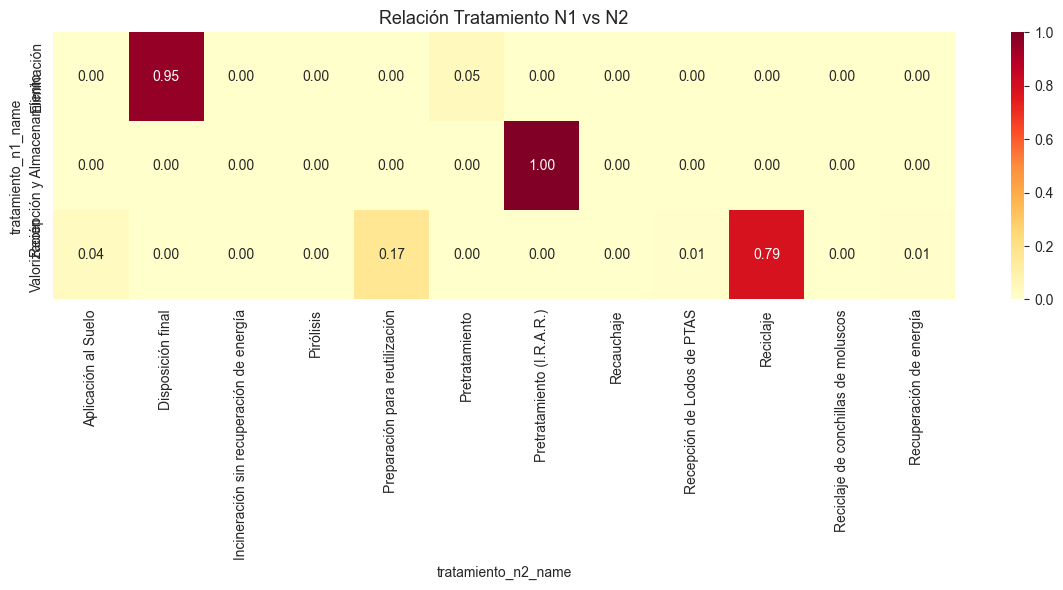

In [12]:
# 3. Región vs Tratamiento_n1
ct3 = pd.crosstab(df['region'], df['tratamiento_n1_name'], normalize='index').sort_values('Eliminación', ascending=False)
fig, ax = plt.subplots(figsize=(14, 7))
ct3.plot(kind='barh', stacked=True, ax=ax, colormap='viridis', edgecolor='white')
ax.set_title('Tipo de Tratamiento por Región', fontsize=13)
ax.set_xlabel('Proporción')
ax.set_ylabel('Región')
ax.legend(title='Tratamiento N1', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# 4. Relación entre tratamiento_n1 y tratamiento_n2
ct4 = pd.crosstab(df['tratamiento_n1_name'], df['tratamiento_n2_name'], normalize='index')
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct4, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Relación Tratamiento N1 vs N2', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
df['rubro'].nunique()

19

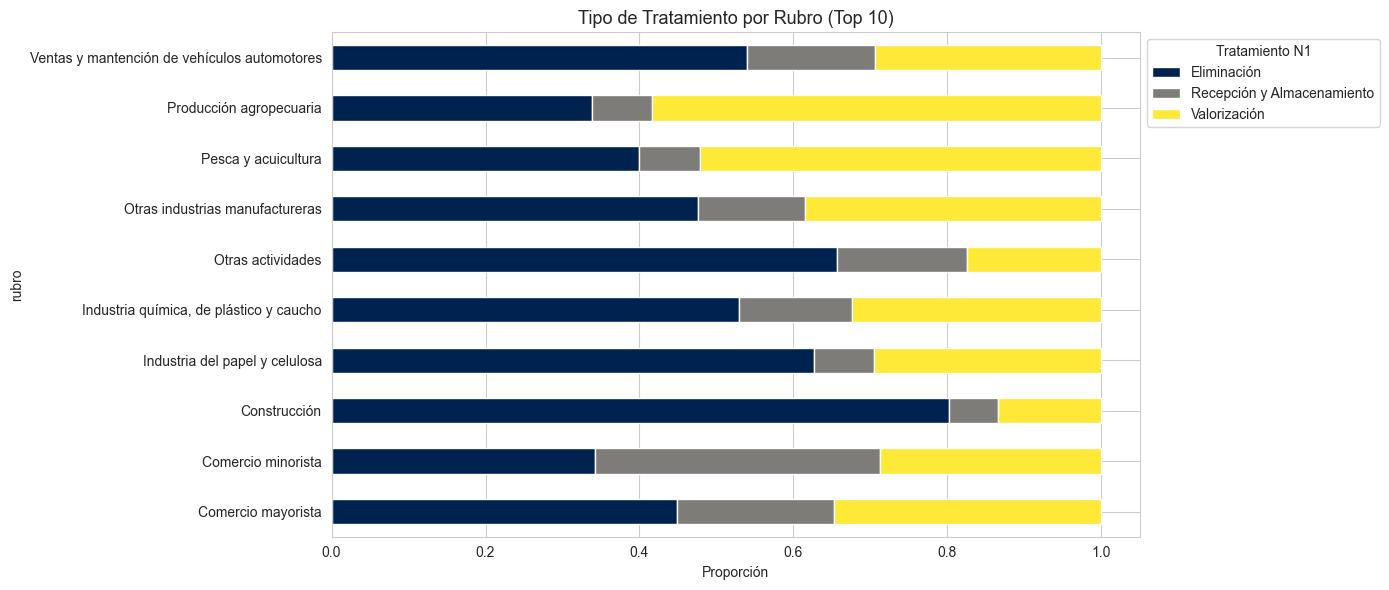

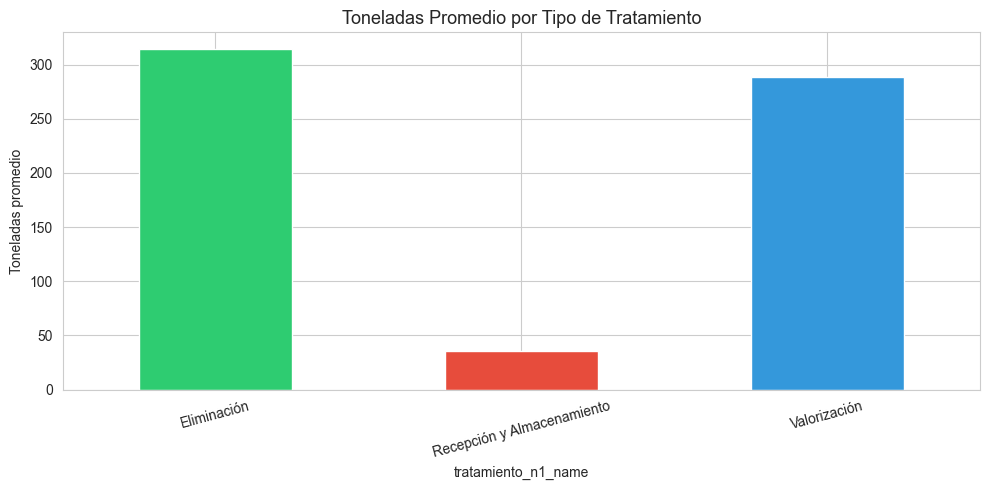

In [14]:
top_rubros = df['rubro'].value_counts().head(10).index
df_top_rubro = df[df['rubro'].isin(top_rubros)]
ct5 = pd.crosstab(df_top_rubro['rubro'], df_top_rubro['tratamiento_n1_name'], normalize='index')
fig, ax = plt.subplots(figsize=(14, 6))
ct5.plot(kind='barh', stacked=True, ax=ax, colormap='cividis', edgecolor='white')
ax.set_title('Tipo de Tratamiento por Rubro (Top 10)', fontsize=13)
ax.set_xlabel('Proporción')
ax.legend(title='Tratamiento N1', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# 6. Toneladas promedio por tratamiento_n1
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('tratamiento_n1_name')['cantidad_toneladas_num'].mean().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='white')
ax.set_title('Toneladas Promedio por Tipo de Tratamiento', fontsize=13)
ax.set_ylabel('Toneladas promedio')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

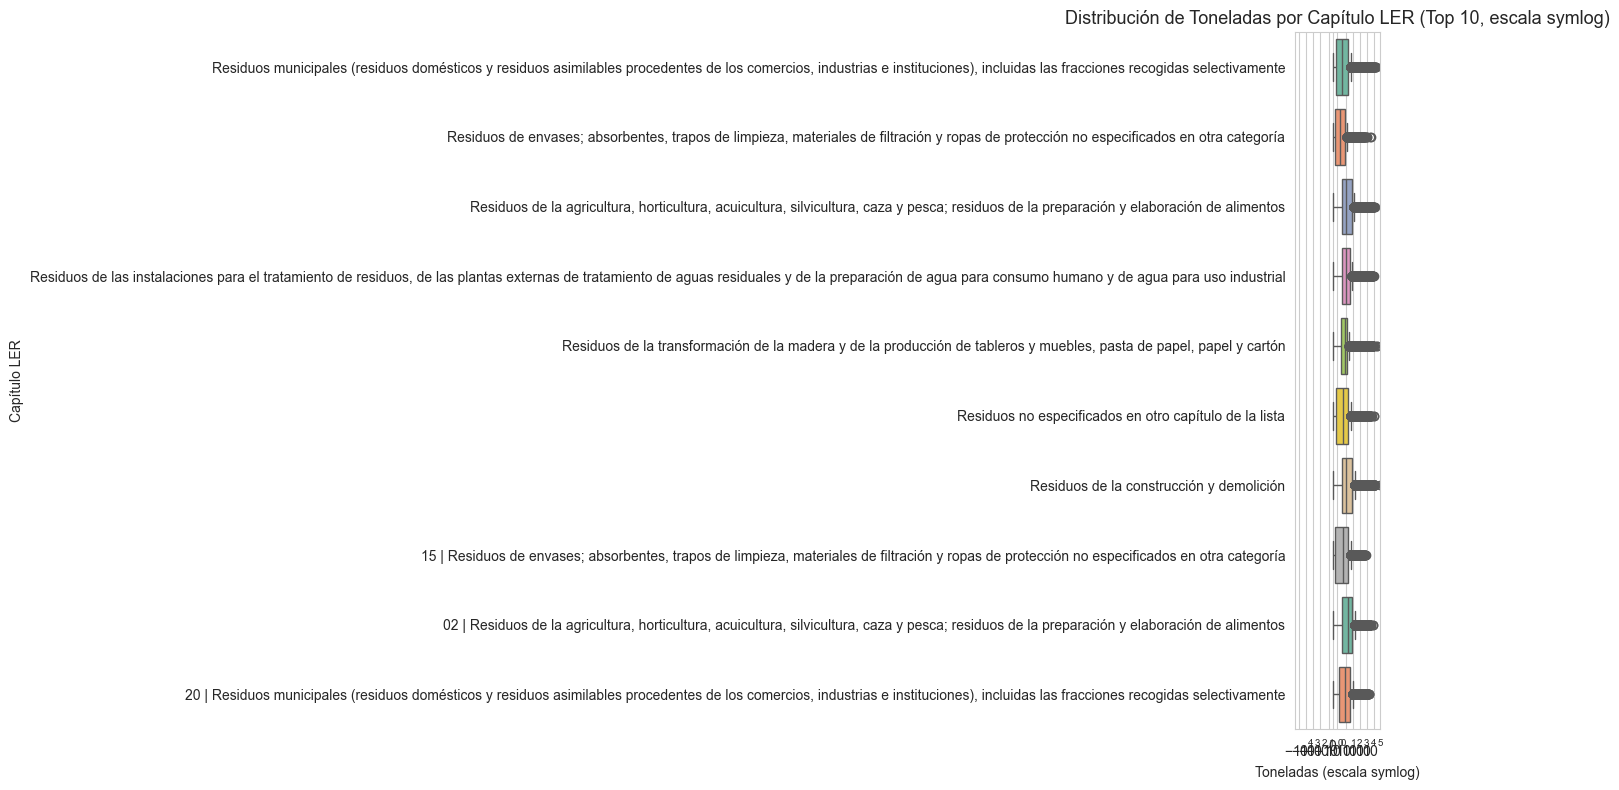

In [15]:
# 7. Cantidad de toneladas vs LER capítulo (top 10)
top_ler = df['ler_capitulo'].value_counts().head(10).index
df_top_ler = df[df['ler_capitulo'].isin(top_ler)]
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df_top_ler, y='ler_capitulo', x='cantidad_toneladas_num', ax=ax, palette='Set2')
ax.set_xscale('symlog')
ax.set_title('Distribución de Toneladas por Capítulo LER (Top 10, escala symlog)', fontsize=13)
ax.set_xlabel('Toneladas (escala symlog)')
ax.set_ylabel('Capítulo LER')
plt.tight_layout()
plt.show()

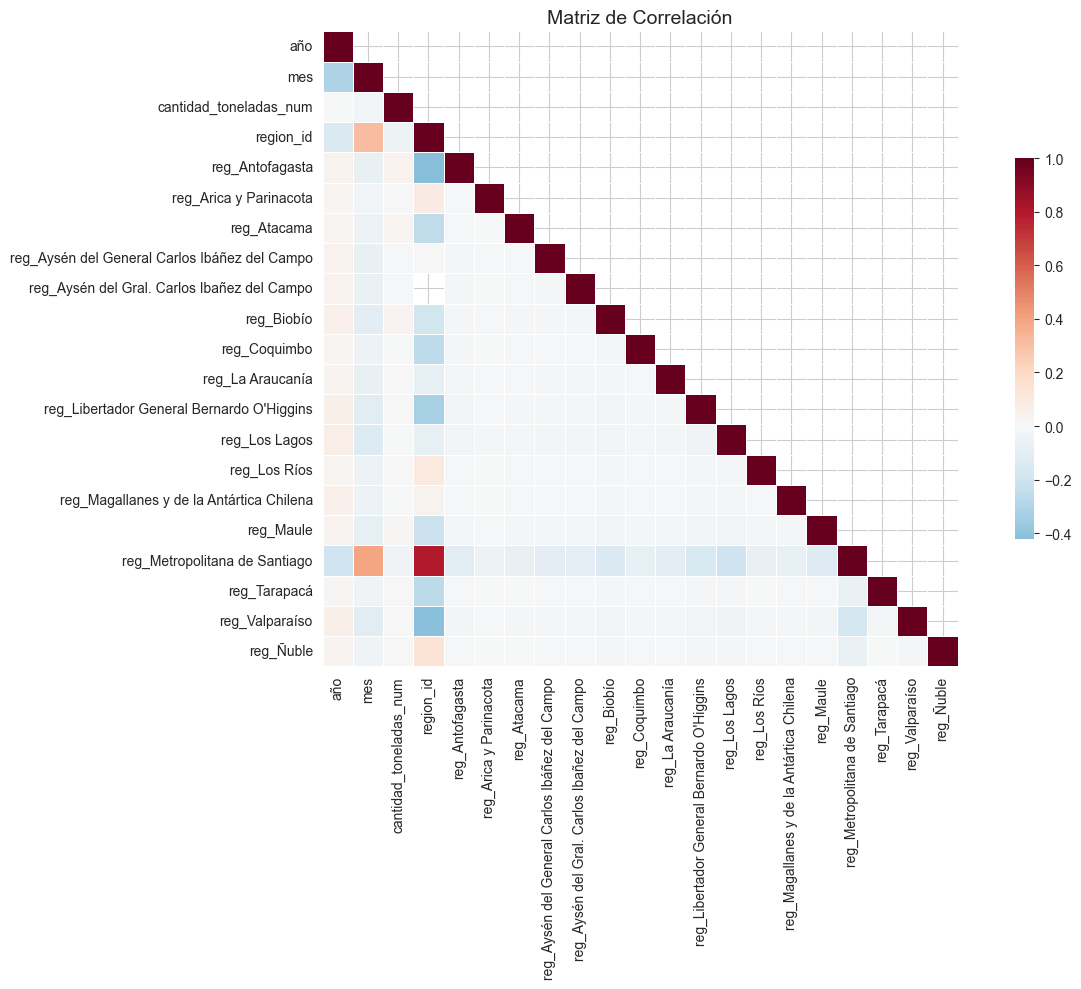

In [16]:
# 8. Matriz de correlación de variables numéricas
num_cols = ['año', 'mes', 'cantidad_toneladas_num', 'region_id']
corr_df = df[num_cols].copy()
# One-hot encode región para correlación
region_dummies = pd.get_dummies(df['region'], prefix='reg')
# Unir con numéricas existentes
corr_data = pd.concat([df[num_cols].select_dtypes(include=[np.number]), region_dummies], axis=1)
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, annot=False,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

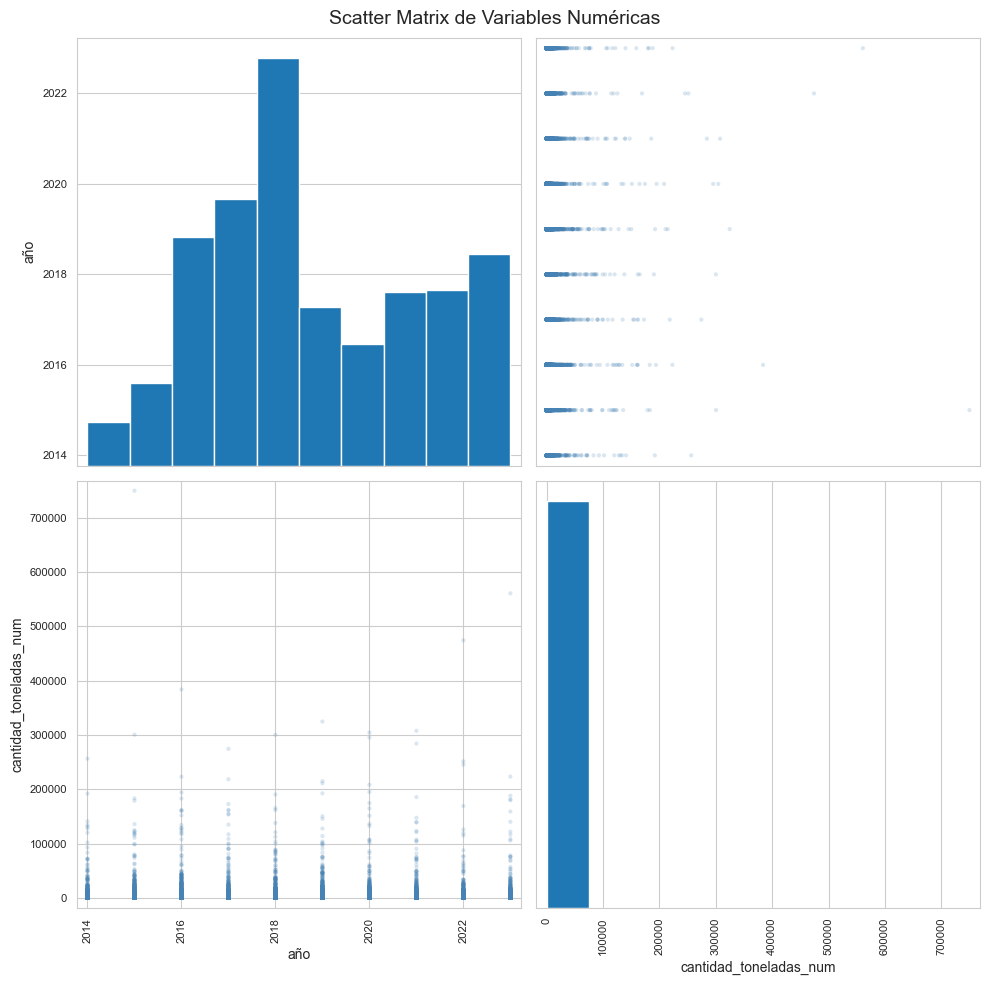

In [17]:
# 9. Pairplot de variables numéricas principales
from pandas.plotting import scatter_matrix
subset = df[['año', 'cantidad_toneladas_num']].dropna()
scatter_matrix(subset, alpha=0.2, figsize=(10, 10), diagonal='hist', color='steelblue')
plt.suptitle('Scatter Matrix de Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

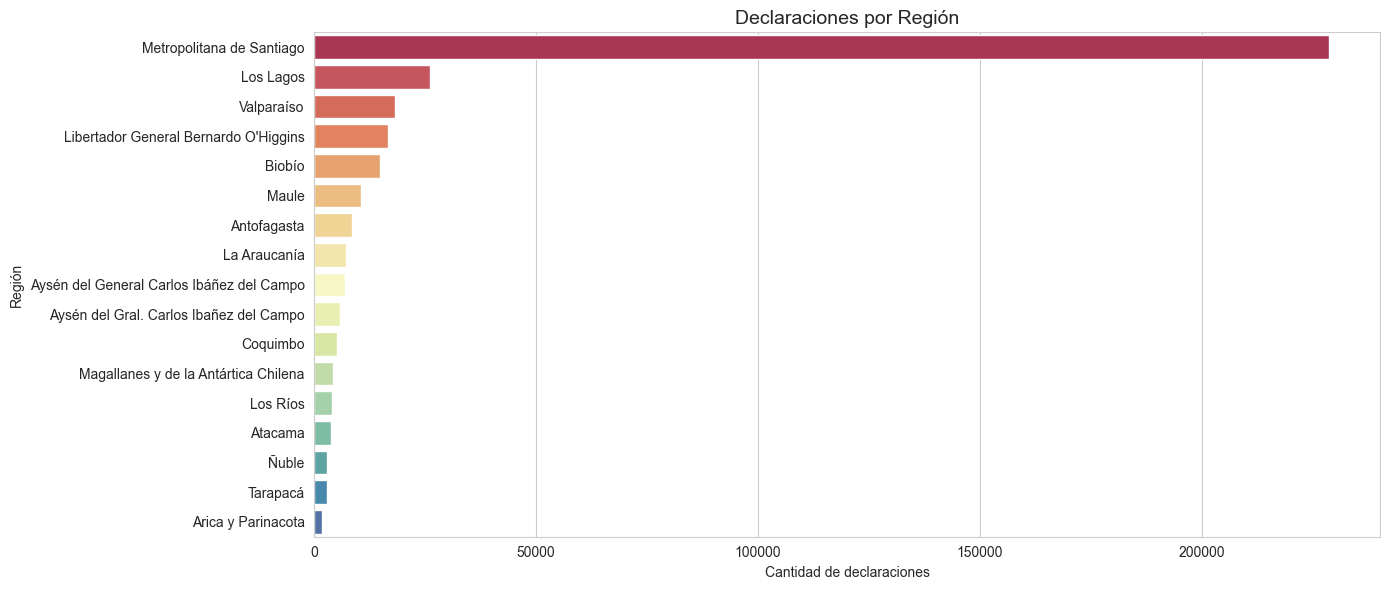

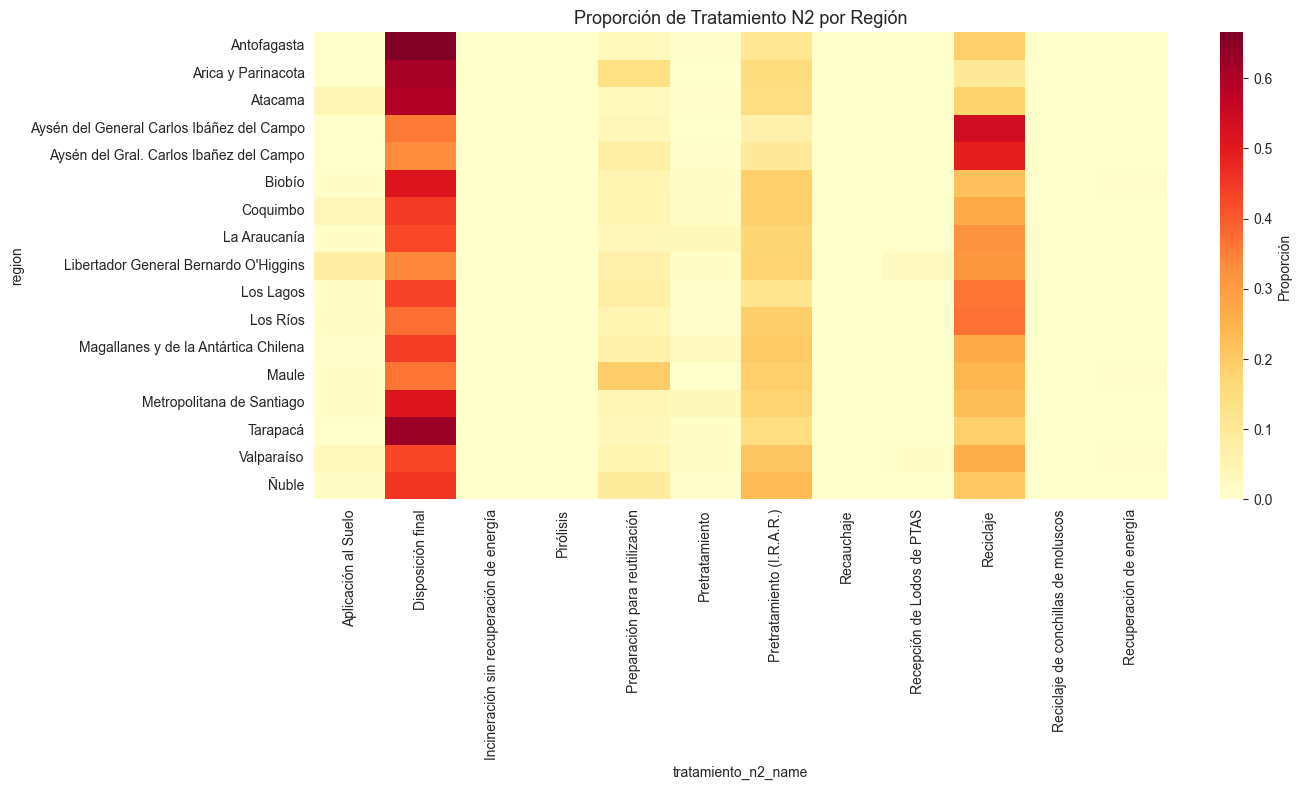

In [18]:
# 10. Gráfico de distribución geográfica
fig, ax = plt.subplots(figsize=(14, 6))
region_order = df['region'].value_counts().index
sns.countplot(data=df, y='region', order=region_order, ax=ax, palette='Spectral')
ax.set_title('Declaraciones por Región', fontsize=14)
ax.set_xlabel('Cantidad de declaraciones')
ax.set_ylabel('Región')
plt.tight_layout()
plt.show()

# 11. Heatmap región vs tratamiento_n2
ct_region_n2 = pd.crosstab(df['region'], df['tratamiento_n2_name'], normalize='index')
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(ct_region_n2, annot=False, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Proporción'})
ax.set_title('Proporción de Tratamiento N2 por Región', fontsize=13)
plt.tight_layout()
plt.show()

# 3. Tratamiento de los Datos

## 3.1 Creación de la Variable "organico"

Definición de residuo orgánico basada en la clasificación LER (Lista Europea de Residuos):

- Capítulo 02: Residuos de agricultura, horticultura, acuicultura, silvicultura, caza, pesca y preparación de alimentos
- Capítulo 03: Residuos de la transformación de la madera y producción de papel/cartón
- Subcapítulos específicos del Capítulo 20: fracciones biodegradables (20 01, 20 02)
- Subcapítulos del Capítulo 19: lodos de depuradora (19 08)
- Cualquier residuo que contenga "orgánico" en su descripción

In [19]:
print('Distribución de ler_numero_capitulo:')
print(df['ler_numero_capitulo'].value_counts().sort_index())
print()

# Definir condición para orgánico
organic_condition = (
    (df['ler_numero_capitulo'] == 2) |  # Agricultura, alimentos
    (df['ler_numero_capitulo'] == 3) |  # Madera, papel
    (df['ler_capitulo'].str.contains('org[aá]nico|orgánica|orgánicos|orgánicas', case=False, na=False)) |
    (df['ler_subcapitulo'].str.contains('org[aá]nico|orgánica|orgánicos|orgánicas|biodegradable|parques y jardines|alimentos|cocina|restaurante', 
                                          case=False, na=False)) |
    # Subcapítulos específicos del capítulo 20: biodegradables
    ((df['ler_numero_capitulo'] == 20) & 
     (df['ler_subcapitulo'].str.contains('Fracciones recogidas selectivamente', case=False, na=False))) |
    # Lodos orgánicos del capítulo 19
    ((df['ler_numero_capitulo'] == 19) & 
     (df['ler_subcapitulo'].str.contains('aguas residuales|tratamiento anaeróbico|tratamiento aeróbico', case=False, na=False)))
)

df['organico'] = organic_condition.astype(int)
print('Distribución de la variable ORGANICO:')
print(df['organico'].value_counts())
print(f'\nPorcentaje orgánico: {df["organico"].mean()*100:.2f}%')

# Validación rápida
print('\n--- Ejemplos de residuos orgánicos ---')
print(df[df['organico']==1][['ler_capitulo', 'ler_subcapitulo', 'organico']].drop_duplicates().head(10).to_string(index=False))

print('\n--- Ejemplos de residuos NO orgánicos ---')
print(df[df['organico']==0][['ler_capitulo', 'ler_subcapitulo', 'organico']].drop_duplicates().head(10).to_string(index=False))

Distribución de ler_numero_capitulo:
ler_numero_capitulo
1.0       2424
2.0      46039
3.0      21252
4.0       1352
5.0         70
6.0        475
7.0       1414
8.0        911
9.0         83
10.0      2579
11.0       257
12.0      4745
15.0     16589
16.0      7278
17.0     17166
18.0       446
19.0     10984
20.0    155843
Name: count, dtype: int64



Distribución de la variable ORGANICO:
organico
0    361816
1    158529
Name: count, dtype: int64

Porcentaje orgánico: 30.47%

--- Ejemplos de residuos orgánicos ---
                                                                                                                                                                                           ler_capitulo                                                                                                                                                                                                                        ler_subcapitulo  organico
                          Residuos municipales (residuos domésticos y residuos asimilables procedentes de los comercios, industrias e instituciones), incluidas las fracciones recogidas selectivamente                                                                                                                                                Fracciones recogidas selectivamente (excepto las e

In [20]:

organico_counts = df.query("organico == 1")['rubro'].value_counts()

mejores_rubros = organico_counts.nlargest(20).index

total_counts = df['rubro'].value_counts()

proporcion = organico_counts[mejores_rubros] / total_counts[mejores_rubros]

print(proporcion.nlargest(20))

rubro
Industria del papel y celulosa                   0.782056
Pesca y acuicultura                              0.681997
Captación, tratamiento y distribución de agua    0.655197
Gestores de residuos                             0.543636
Industria de la madera y silvicultura            0.504071
Otras industrias manufactureras                  0.477312
Plantas de tratamiento de aguas servidas         0.432558
Comercio minorista                               0.409526
Producción agropecuaria                          0.381046
Industria química, de plástico y caucho          0.378412
Comercio mayorista                               0.377591
Otras actividades                                0.318168
Ventas y mantención de vehículos automotores     0.232720
Minería                                          0.194503
Refinería de petróleo                            0.184987
Termoeléctricas                                  0.175190
Otras centrales de generación eléctrica          0.113841
Producci

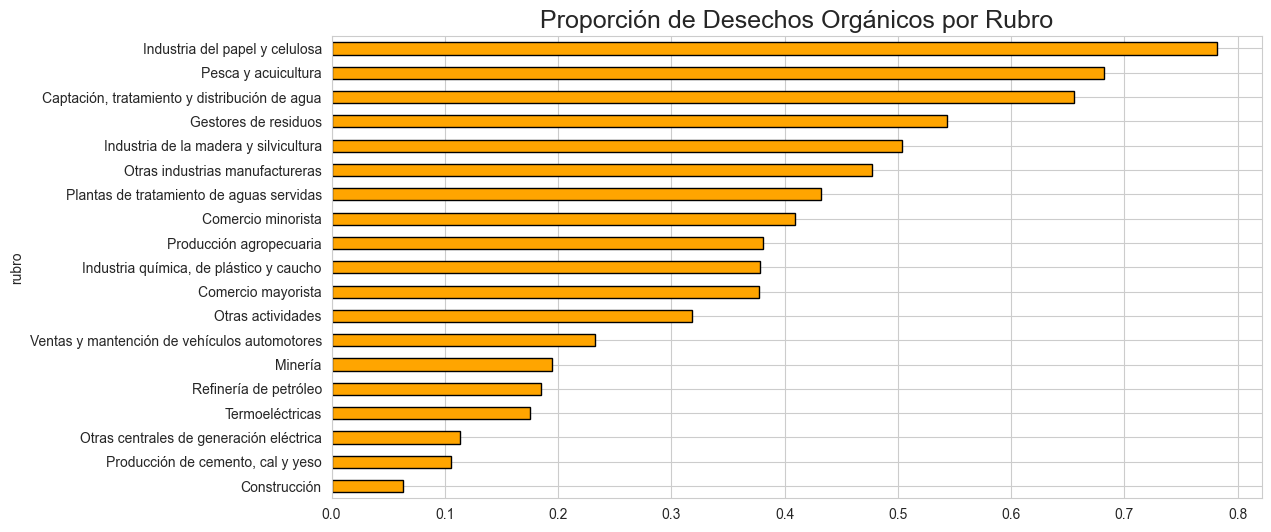

In [21]:
proporcion.sort_values(ascending=True).plot(kind='barh',color='orange',edgecolor='black')
plt.title('Proporción de Desechos Orgánicos por Rubro',fontsize=18)
plt.show()

In [22]:
df.query("organico ==0")['rubro'].value_counts().tail(10)

rubro
Minería                                          4572
Industria del papel y celulosa                   3583
Otras centrales de generación eléctrica          2958
Gestores de residuos                             2144
Termoeléctricas                                  1629
Captación, tratamiento y distribución de agua    1443
Industria de la madera y silvicultura            1401
Plantas de tratamiento de aguas servidas          732
Producción de cemento, cal y yeso                 711
Refinería de petróleo                             304
Name: count, dtype: int64

In [23]:
df.query("organico ==1")['rubro'].value_counts().tail(10)


rubro
Gestores de residuos                            2554
Ventas y mantención de vehículos automotores    1936
Industria de la madera y silvicultura           1424
Minería                                         1104
Construcción                                     577
Plantas de tratamiento de aguas servidas         558
Otras centrales de generación eléctrica          380
Termoeléctricas                                  346
Producción de cemento, cal y yeso                 84
Refinería de petróleo                             69
Name: count, dtype: int64

In [24]:
df_organico =df.query("organico ==1")

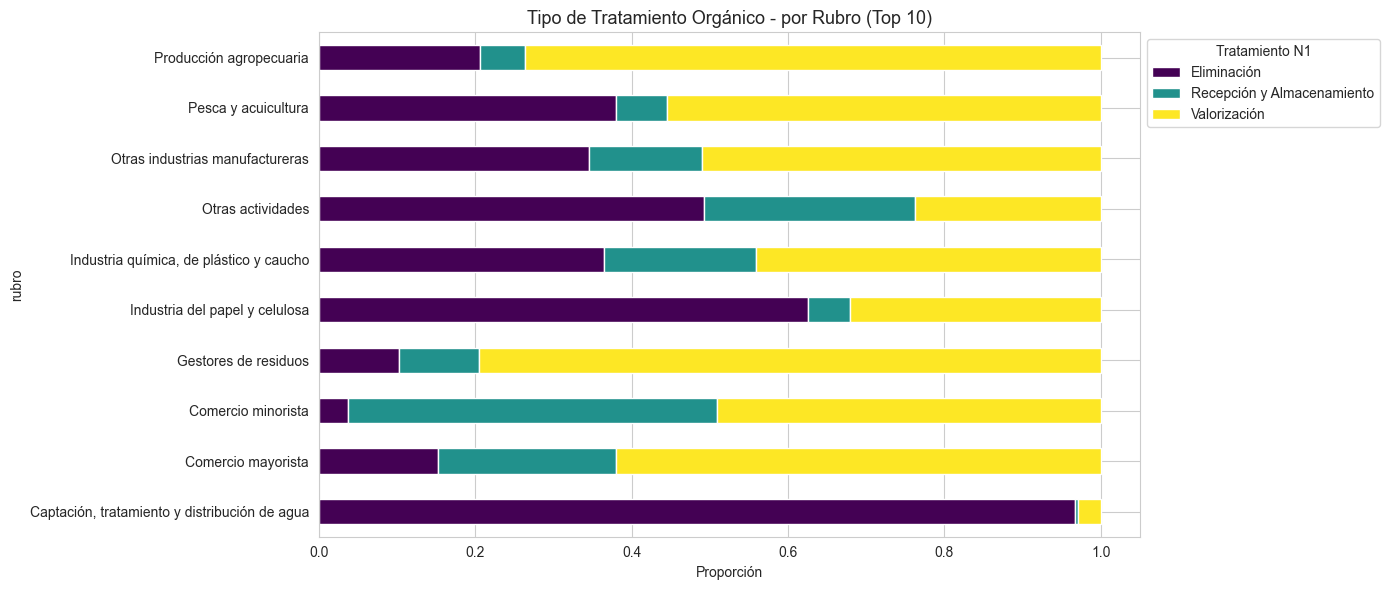

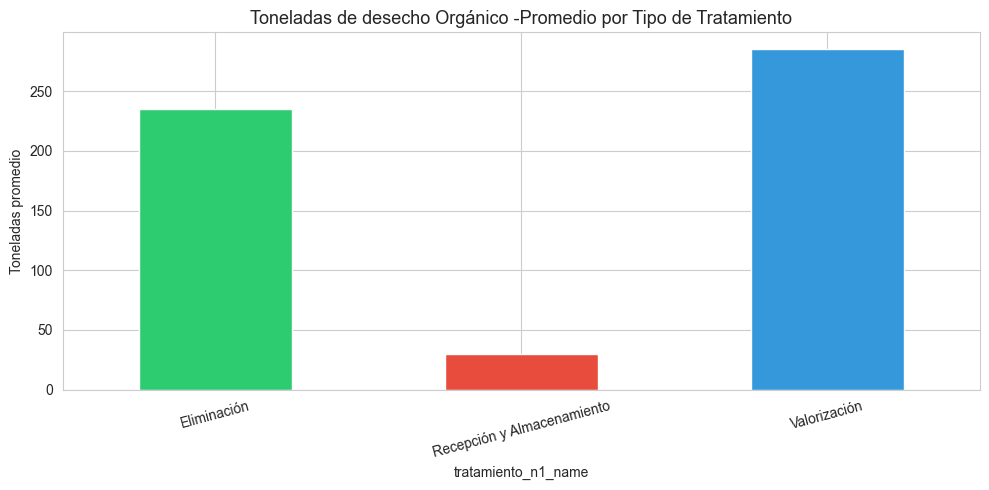

In [25]:
# 5. Rubro (top 10) vs Tratamiento_n1
top_rubros = df_organico['rubro'].value_counts().head(10).index
df_top_rubro = df_organico[df_organico['rubro'].isin(top_rubros)]
ct5 = pd.crosstab(df_top_rubro['rubro'], df_top_rubro['tratamiento_n1_name'], normalize='index')
fig, ax = plt.subplots(figsize=(14, 6))
ct5.plot(kind='barh', stacked=True, ax=ax, colormap='viridis', edgecolor='white')
ax.set_title('Tipo de Tratamiento Orgánico - por Rubro (Top 10)', fontsize=13)
ax.set_xlabel('Proporción')
ax.legend(title='Tratamiento N1', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# 6. Toneladas promedio por tratamiento_n1
fig, ax = plt.subplots(figsize=(10, 5))
df_organico.groupby('tratamiento_n1_name')['cantidad_toneladas_num'].mean().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='white')
ax.set_title('Toneladas de desecho Orgánico -Promedio por Tipo de Tratamiento', fontsize=13)
ax.set_ylabel('Toneladas promedio')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 3.2 Limpieza y Estandarización de Variables

In [26]:
# Estandarizar cantidad_toneladas (de string con coma a float)
df['cantidad_toneladas_num'] = (
    df['cantidad_toneladas']
    .str.replace(',', '.', regex=False)
    .str.replace(r'[^0-9\.\-]', '', regex=True)
)
df['cantidad_toneladas_num'] = pd.to_numeric(df['cantidad_toneladas_num'], errors='coerce')
print(f'Valores nulos en cantidad_toneladas_num después de conversión: {df["cantidad_toneladas_num"].isnull().sum()}')

# Aplicar log1p para reducir asimetría
df['toneladas_log'] = np.log1p(df['cantidad_toneladas_num'].fillna(0))

# Crear columna año-mes para orden temporal
df['fecha'] = pd.to_datetime(df['año'].astype(str) + '-' + df['mes'].astype(str) + '-01', errors='coerce')

Valores nulos en cantidad_toneladas_num después de conversión: 152623


## 3.3 Tratamiento de Valores Nulos

In [27]:
print('Estado actual de nulos:')
null_summary = df.isnull().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)
display(null_summary.to_frame('Nulos'))

# Estrategia de tratamiento:

# 1. Columnas con > 50% nulos - se eliminan (no aportan información suficiente)
cols_drop = ['rubro_id', 'declaracion_id', 'tipo_recepcion']
print(f'\nColumnas eliminadas (>50% nulos o irrelevantes): {cols_drop}')
df.drop(columns=cols_drop, inplace=True)

# 2. Columnas de texto con pocos nulos - imputar con 'Desconocido' o 'Sin Info'
text_cols_fill = ['razon_social', 'nombre_establecimiento', 'rubro', 'ciiu4', 'ciiu4_id', 
                  'ciiu6', 'ciiu6_id', 'latitud', 'longitud', 'trazabilidad__nombre_establecimiento',
                  'trazabilidad__razon_social', 'trazabilidad__comuna', 'trazabilidad__region',
                  'trazabilidad__pais']
for col in text_cols_fill:
    if col in df.columns:
        df[col] = df[col].fillna('Desconocido')

# 3. Variable region_id - imputar con la moda por región
if 'region_id' in df.columns:
    region_mode = df.groupby('region')['region_id'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    df['region_id'] = df['region_id'].fillna(region_mode)
    df['region_id'] = df['region_id'].fillna(df['region_id'].mode().iloc[0])

# 4. Variables de tratamiento con nulos - imputar con moda
for col in ['tratamiento_n1_id', 'tratamiento_n1_name', 'tratamiento_n2_id', 'tratamiento_n2_name',
            'tratamiento_n3_id', 'tratamiento_n3_name']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode().iloc[0] if not df[col].mode().empty else 'Desconocido')

# 5. Variables LER con nulos
ler_fill_map = {
    'ler_numero': 0,
    'ler_numero_capitulo': 0,
    'ler_numero_subcapitulo': 0,
    'codigo_unico_territorial': 0
}
for col, val in ler_fill_map.items():
    if col in df.columns:
        df[col] = df[col].fillna(val)

# 6. Variables de trazabilidad
for col in ['trazabilidad__id_vu']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print('\n--- Nulos después del tratamiento ---')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else '¡No hay más valores nulos!')

Estado actual de nulos:


,Nulos
declaracion_id,520345
fecha,520345
tipo_recepcion,520345
rubro_id,502009
"aÃ±o,mes,id_vu,razon_social,rut_razon_social,nombre_establecimiento,rubro,rubro_id,ciiu4,ciiu4_id,ciiu6,ciiu6_id,region,provincia,comuna,codigo_unico_territorial,latitud,longitud,rol_establecimiento,declaracion_id,tipo_recepcion,cantidad_toneladas,tratamiento_n1_id,tratamiento_n1_name,tratamiento_n2_id,tratamiento_n2_name,tratamiento_n3_id,tratamiento_n3_name,LER,LER_numero,LER_capitulo,LER_numero_capitulo,LER_subcapitulo,LER_numero_subcapitulo,trazabilidad__id_vu,trazabilidad__nombre_establecimiento,trazabilidad__razon_social,trazabilidad__comuna,trazabilidad__region,trazabilidad__pais",367722
trazabilidad__id_vu,280239
trazabilidad__region,272917
trazabilidad__pais,272917
trazabilidad__comuna,272917
trazabilidad__nombre_establecimiento,271556



Columnas eliminadas (>50% nulos o irrelevantes): ['rubro_id', 'declaracion_id', 'tipo_recepcion']



--- Nulos después del tratamiento ---
año                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  152623
mes                                                                                                                                                                                                                                                                                                                                                                  

In [28]:
df.isnull().sum()



año                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  152623
mes                                                                                                                                                                                                                                                                                                                                                                                                         

## 3.4 Feature Engineering Adicional

In [29]:
# Agrupar tratamientos minoritarios en tratamiento_n2_name
n2_counts = df['tratamiento_n2_name'].value_counts()
rare_n2 = n2_counts[n2_counts < 1000].index
print(f'Categorías minoritarias de tratamiento_n2_name a agrupar: {len(rare_n2)}')
df['tratamiento_n2_agg'] = df['tratamiento_n2_name'].apply(
    lambda x: 'Otros' if x in rare_n2 else x
)
print('\nDistribución después de agrupar:')
print(df['tratamiento_n2_agg'].value_counts())

# REGION_ID: codificar numéricamente
region_map = {reg: i for i, reg in enumerate(df['region'].unique())}
df['region_encoded'] = df['region'].map(region_map)

# Crear variable de interacción: cantidad_toneladas * tipo LER (simplificado)
df['ton_por_capitulo'] = df.groupby('ler_numero_capitulo')['cantidad_toneladas_num'].transform('mean')

# Variable: si el residuo es municipal
df['es_municipal'] = (df['ler_numero_capitulo'] == 20).astype(int)

print('\nNuevas características creadas:')
for col in ['tratamiento_n2_agg', 'region_encoded', 'ton_por_capitulo', 'es_municipal']:
    print(f'  -> {col}: {df[col].dtype}')

Categorías minoritarias de tratamiento_n2_name a agrupar: 6



Distribución después de agrupar:
tratamiento_n2_agg
Disposición final                 338011
Reciclaje                          89544
Pretratamiento (I.R.A.R.)          60045
Preparación para reutilización     18957
Pretratamiento                      8228
Aplicación al Suelo                 4255
Otros                               1305
Name: count, dtype: int64

Nuevas características creadas:
  -> tratamiento_n2_agg: str
  -> region_encoded: int64
  -> ton_por_capitulo: float64
  -> es_municipal: int64


# 4. Modelamiento

## Estrategia

Dos **variables objetivo**:
1. **`organico`** (binaria: 0/1) - Clasificación binaria
2. **`tratamiento_n2_agg`** (multiclase) - Clasificación multiclase

Dos **estrategias de partición**:
1. **Serie temporal** (70/15/15 por año)
2. **Aleatoria** (70/15/15 random)

Para cada combinación: **LightGBM**, **Decision Tree**, **Regresión Logística** + **Cross-Validation** con folds.

Al final: **comparación con LSTM**.

In [30]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import lightgbm as lgb
import time
import warnings
warnings.filterwarnings('ignore')

# Configuración global
RANDOM_STATE = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15
N_FOLDS = 5

# Features base para modeling
feature_cols = [
    'año', 'mes', 'cantidad_toneladas_num', 'toneladas_log',
    'region_encoded', 'ler_numero_capitulo', 'ler_numero_subcapitulo',
    'ton_por_capitulo', 'es_municipal'
]

# Preparar datos base
base = df[feature_cols].copy()
base = base.fillna(0)  # Por si acaso

# Para la variable objetivo organico
base['organico'] = df['organico'].values

# Para tratamiento_n2_agg - codificar
le_n2 = LabelEncoder()
base['tratamiento_n2_enc'] = le_n2.fit_transform(df['tratamiento_n2_agg'])
target_n2_classes = le_n2.classes_
print(f'Clases de tratamiento_n2_agg: {len(target_n2_classes)}')
print(target_n2_classes)

Clases de tratamiento_n2_agg: 7
['Aplicación al Suelo' 'Disposición final' 'Otros'
 'Preparación para reutilización' 'Pretratamiento'
 'Pretratamiento (I.R.A.R.)' 'Reciclaje']


## 4.1 Partición Temporal (Time Series Split)

Separación basada en año: años antiguos → train, medios → val, recientes → test

In [31]:
# Partición temporal (70/15/15 basado en año)
years = sorted(df['año'].unique())
n_years = len(years)
n_train_years = int(n_years * 0.7)
n_val_years = int(n_years * 0.15)

train_years = years[:n_train_years]
val_years = years[n_train_years:n_train_years + n_val_years]
test_years = years[n_train_years + n_val_years:]

print(f'Años disponibles: {years}')
print(f'Train años ({len(train_years)}): {train_years}')
print(f'Val años ({len(val_years)}): {val_years}')
print(f'Test años ({len(test_years)}): {test_years}')

# Crear máscaras
train_mask = df['año'].isin(train_years)
val_mask = df['año'].isin(val_years)
test_mask = df['año'].isin(test_years)

print(f'\nTrain: {train_mask.sum():,} registros ({train_mask.sum()/len(df)*100:.1f}%)')
print(f'Val:   {val_mask.sum():,} registros ({val_mask.sum()/len(df)*100:.1f}%)')
print(f'Test:  {test_mask.sum():,} registros ({test_mask.sum()/len(df)*100:.1f}%)')

# Datasets temporales
X_train_ts = base.loc[train_mask, feature_cols]
y_train_org_ts = base.loc[train_mask, 'organico']
y_train_n2_ts = base.loc[train_mask, 'tratamiento_n2_enc']

X_val_ts = base.loc[val_mask, feature_cols]
y_val_org_ts = base.loc[val_mask, 'organico']
y_val_n2_ts = base.loc[val_mask, 'tratamiento_n2_enc']

X_test_ts = base.loc[test_mask, feature_cols]
y_test_org_ts = base.loc[test_mask, 'organico']
y_test_n2_ts = base.loc[test_mask, 'tratamiento_n2_enc']

Años disponibles: [np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(nan)]
Train años (7): [np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0)]
Val años (1): [np.float64(2021.0)]
Test años (3): [np.float64(2022.0), np.float64(2023.0), np.float64(nan)]

Train: 257,337 registros (49.5%)
Val:   34,196 registros (6.6%)
Test:  228,812 registros (44.0%)


## 4.2 Partición Aleatoria (Random Split)

In [32]:
# Partición aleatoria estratificada 70/15/15
# Estratificar por organico para mantener proporción
X_temp, X_test_rd, y_temp_org, y_test_org_rd, idx_temp, idx_test = train_test_split(
    base[feature_cols], base['organico'], base.index, test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, stratify=base['organico']
)

val_ratio_adjusted = VAL_SIZE / (1 - TEST_SIZE)
X_train_rd, X_val_rd, y_train_org_rd, y_val_org_rd = train_test_split(
    X_temp, y_temp_org, test_size=val_ratio_adjusted, 
    random_state=RANDOM_STATE, stratify=y_temp_org
)

# Para tratamiento_n2_agg (estratificado)
_, _, y_temp_n2, y_test_n2_rd, _, _ = train_test_split(
    base[feature_cols], base['tratamiento_n2_enc'], base.index, 
    test_size=TEST_SIZE, random_state=RANDOM_STATE, 
    stratify=base['tratamiento_n2_enc']
)

X_train_n2_rd, X_val_n2_rd, y_train_n2_rd, y_val_n2_rd = train_test_split(
    X_temp, y_temp_n2, test_size=val_ratio_adjusted, 
    random_state=RANDOM_STATE, stratify=y_temp_n2
)

print('=== Partición Aleatoria ===')
print(f'Train: {len(X_train_rd):,} ({len(X_train_rd)/len(base)*100:.1f}%)')
print(f'Val:   {len(X_val_rd):,} ({len(X_val_rd)/len(base)*100:.1f}%)')
print(f'Test:  {len(X_test_rd):,} ({len(X_test_rd)/len(base)*100:.1f}%)')

print(f'\nDistribución organico en train:')
print(y_train_org_rd.value_counts(normalize=True))

=== Partición Aleatoria ===
Train: 364,241 (70.0%)
Val:   78,052 (15.0%)
Test:  78,052 (15.0%)

Distribución organico en train:
organico
0    0.695339
1    0.304661
Name: proportion, dtype: float64


---
# 5. Modelos - Variable Objetivo: **organico** (Clasificación Binaria)
---

## 5.1 Partición Temporal

In [33]:
def evaluate_binary(y_true, y_pred, y_proba=None, dataset_name=''):
    result = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }
    if y_proba is not None:
        try:
            result['roc_auc'] = roc_auc_score(y_true, y_proba)
        except:
            result['roc_auc'] = np.nan
    print(f'  {dataset_name}: Acc={result["accuracy"]:.4f}, Prec={result["precision"]:.4f}, '
          f'Rec={result["recall"]:.4f}, F1={result["f1"]:.4f}', end='')
    if 'roc_auc' in result:
        print(f', AUC={result["roc_auc"]:.4f}')
    else:
        print()
    return result

def train_test_model_org(model, model_name, X_tr, y_tr, X_v, y_v, X_te, y_te, split_name):
    print(f'\n{"="*60}')
    print(f'{model_name} - {split_name}')
    print(f'{"="*60}')
    
    # Train
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    
    # Predict
    y_pred_tr = model.predict(X_tr)
    y_pred_val = model.predict(X_v)
    y_pred_te = model.predict(X_te)
    
    # Probabilidades
    y_proba_tr = model.predict_proba(X_tr)[:, 1] if hasattr(model, 'predict_proba') else None
    y_proba_val = model.predict_proba(X_v)[:, 1] if hasattr(model, 'predict_proba') else None
    y_proba_te = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    print(f'  Tiempo entrenamiento: {train_time:.3f}s')
    res_train = evaluate_binary(y_tr, y_pred_tr, y_proba_tr, 'Train')
    res_val = evaluate_binary(y_v, y_pred_val, y_proba_val, 'Validation')
    res_test = evaluate_binary(y_te, y_pred_te, y_proba_te, 'Test')
    
    return {'model': model, 'name': model_name, 'train': res_train, 'val': res_val, 'test': res_test}

# ======= MODELOS: organico + partición temporal =======

results_org_ts = []

# LightGBM
lgb_org = lgb.LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.05,
                              random_state=RANDOM_STATE, verbose=-1)
results_org_ts.append(train_test_model_org(lgb_org, 'LightGBM', 
    X_train_ts, y_train_org_ts, X_val_ts, y_val_org_ts, X_test_ts, y_test_org_ts, 'Organico - Temporal'))

# Decision Tree
dt_org = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=RANDOM_STATE)
results_org_ts.append(train_test_model_org(dt_org, 'Decision Tree',
    X_train_ts, y_train_org_ts, X_val_ts, y_val_org_ts, X_test_ts, y_test_org_ts, 'Organico - Temporal'))

# Logistic Regression (con escalado)
scaler = StandardScaler()
X_train_ts_scaled = scaler.fit_transform(X_train_ts)
X_val_ts_scaled = scaler.transform(X_val_ts)
X_test_ts_scaled = scaler.transform(X_test_ts)

lr_org = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
# Usar un wrapper para compatibilidad
class LRWrapper:
    def __init__(self, lr, scaler):
        self.lr = lr
        self.scaler = scaler
    def fit(self, X, y):
        return self.lr.fit(self.scaler.transform(X), y)
    def predict(self, X):
        return self.lr.predict(self.scaler.transform(X))
    def predict_proba(self, X):
        return self.lr.predict_proba(self.scaler.transform(X))

lr_wrapped = LRWrapper(lr_org, scaler)
# Reentrenar con datos originales
lr_org.fit(X_train_ts_scaled, y_train_org_ts)
results_org_ts.append(train_test_model_org(lr_org, 'Logistic Regression',
    X_train_ts_scaled, y_train_org_ts, X_val_ts_scaled, y_val_org_ts, 
    X_test_ts_scaled, y_test_org_ts, 'Organico - Temporal'))


LightGBM - Organico - Temporal
  Tiempo entrenamiento: 4.949s
  Train: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, AUC=1.0000
  Validation: Acc=0.9998, Prec=0.9997, Rec=0.9999, F1=0.9998, AUC=0.9998
  Test: Acc=0.9845, Prec=0.0000, Rec=0.0000, F1=0.0000, AUC=0.1863

Decision Tree - Organico - Temporal
  Tiempo entrenamiento: 0.637s
  Train: Acc=0.9995, Prec=0.9992, Rec=0.9999, F1=0.9995, AUC=1.0000
  Validation: Acc=0.9994, Prec=0.9991, Rec=0.9998, F1=0.9995, AUC=0.9998
  Test: Acc=0.9845, Prec=0.0000, Rec=0.0000, F1=0.0000, AUC=0.5000

Logistic Regression - Organico - Temporal
  Tiempo entrenamiento: 1.294s
  Train: Acc=0.9456, Prec=0.9463, Rec=0.9513, F1=0.9488, AUC=0.9289
  Validation: Acc=0.9532, Prec=0.9750, Rec=0.9383, F1=0.9563, AUC=0.9403
  Test: Acc=0.0155, Prec=0.0155, Rec=1.0000, F1=0.0305, AUC=0.1318


## 5.2 Partición Aleatoria

In [34]:
results_org_rd = []

# LightGBM
lgb_org_rd = lgb.LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.05,
                                  random_state=RANDOM_STATE, verbose=-1)
results_org_rd.append(train_test_model_org(lgb_org_rd, 'LightGBM',
    X_train_rd, y_train_org_rd, X_val_rd, y_val_org_rd, X_test_rd, y_test_org_rd, 'Organico - Aleatorio'))

# Decision Tree
dt_org_rd = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=RANDOM_STATE)
results_org_rd.append(train_test_model_org(dt_org_rd, 'Decision Tree',
    X_train_rd, y_train_org_rd, X_val_rd, y_val_org_rd, X_test_rd, y_test_org_rd, 'Organico - Aleatorio'))

# Logistic Regression
scaler_rd = StandardScaler()
X_train_rd_scaled = scaler_rd.fit_transform(X_train_rd)
X_val_rd_scaled = scaler_rd.transform(X_val_rd)
X_test_rd_scaled = scaler_rd.transform(X_test_rd)

lr_org_rd = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
lr_org_rd.fit(X_train_rd_scaled, y_train_org_rd)
results_org_rd.append(train_test_model_org(lr_org_rd, 'Logistic Regression',
    X_train_rd_scaled, y_train_org_rd, X_val_rd_scaled, y_val_org_rd, 
    X_test_rd_scaled, y_test_org_rd, 'Organico - Aleatorio'))


LightGBM - Organico - Aleatorio


  Tiempo entrenamiento: 5.193s
  Train: Acc=0.9935, Prec=0.9988, Rec=0.9797, F1=0.9892, AUC=0.9992
  Validation: Acc=0.9931, Prec=0.9982, Rec=0.9791, F1=0.9886, AUC=0.9990
  Test: Acc=0.9937, Prec=0.9988, Rec=0.9804, F1=0.9895, AUC=0.9989

Decision Tree - Organico - Aleatorio
  Tiempo entrenamiento: 1.625s
  Train: Acc=0.9934, Prec=0.9987, Rec=0.9797, F1=0.9891, AUC=0.9992
  Validation: Acc=0.9930, Prec=0.9980, Rec=0.9791, F1=0.9884, AUC=0.9988
  Test: Acc=0.9936, Prec=0.9987, Rec=0.9804, F1=0.9895, AUC=0.9986

Logistic Regression - Organico - Aleatorio
  Tiempo entrenamiento: 0.635s
  Train: Acc=0.6932, Prec=0.4982, Rec=0.9639, F1=0.6568, AUC=0.7469
  Validation: Acc=0.6933, Prec=0.4983, Rec=0.9656, F1=0.6574, AUC=0.7466
  Test: Acc=0.6921, Prec=0.4972, Rec=0.9658, F1=0.6565, AUC=0.7476


## 5.3 Comparación de Resultados - organico

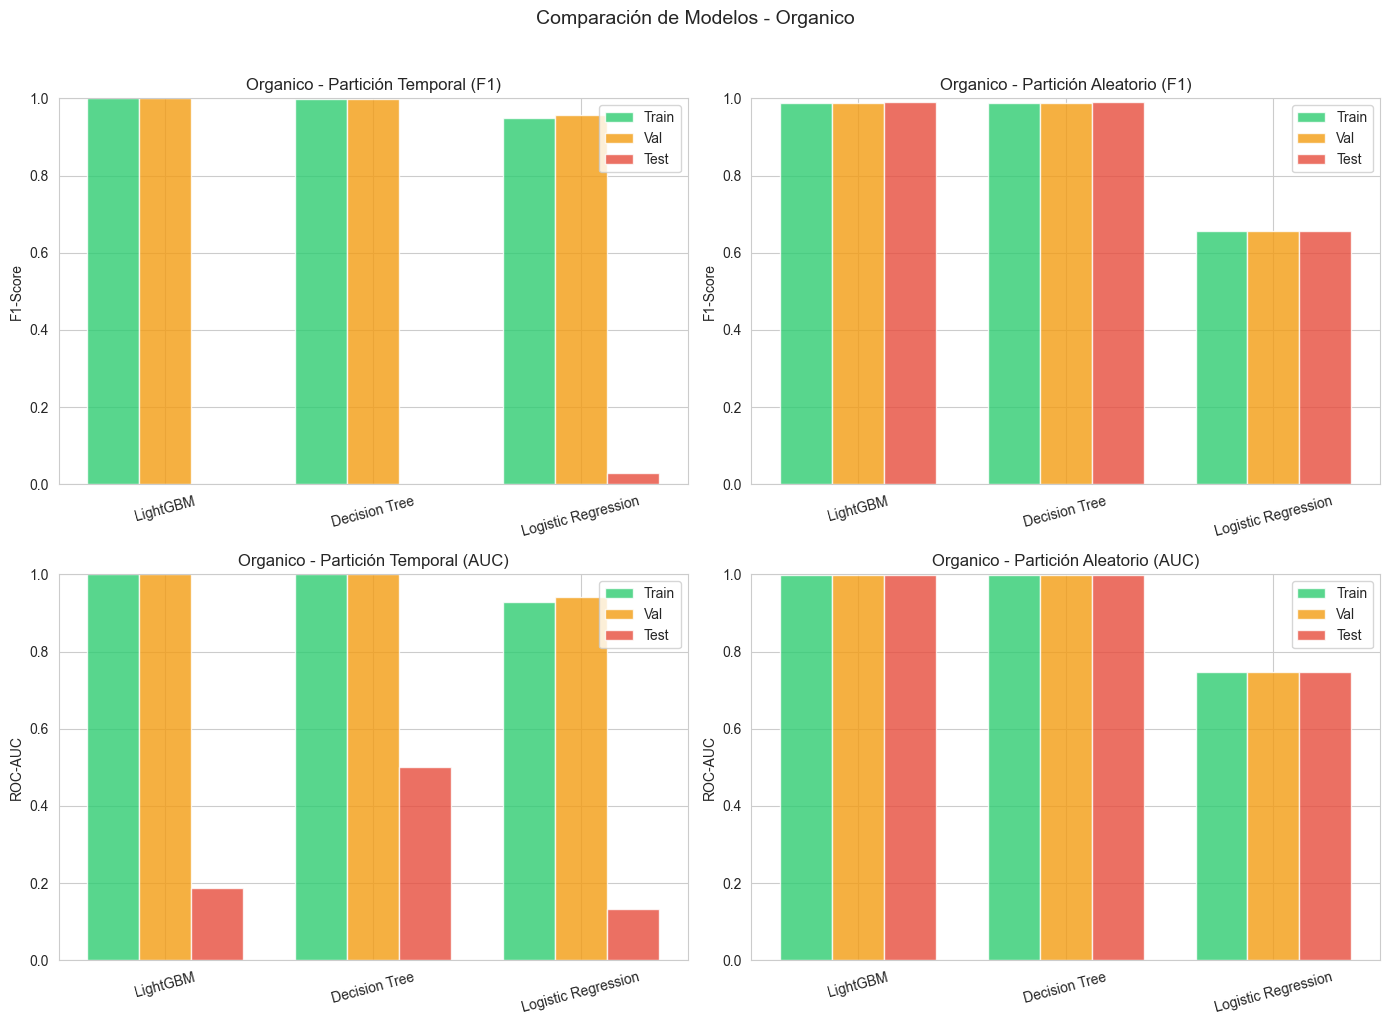

In [35]:
def plot_results_comparison(results_ts, results_rd, target_name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for idx, (results, split_name) in enumerate([(results_ts, 'Temporal'), (results_rd, 'Aleatorio')]):
        models = [r['name'] for r in results]
        metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
        
        train_scores = {m: [] for m in metrics}
        val_scores = {m: [] for m in metrics}
        test_scores = {m: [] for m in metrics}
        
        for r in results:
            for m in metrics:
                if m in r['train']:
                    train_scores[m].append(r['train'][m])
                    val_scores[m].append(r['val'][m])
                    test_scores[m].append(r['test'][m])
                else:
                    train_scores[m].append(np.nan)
                    val_scores[m].append(np.nan)
                    test_scores[m].append(np.nan)
        
        x = np.arange(len(models))
        width = 0.25
        
        ax = axes[idx // 2, idx % 2]
        colors = ['#2ecc71', '#f39c12', '#e74c3c']
        for i, (scores, label, color) in enumerate([
            (train_scores, 'Train', '#2ecc71'),
            (val_scores, 'Val', '#f39c12'),
            (test_scores, 'Test', '#e74c3c')
        ]):
            ax.bar(x + i*width, [scores['f1'][j] for j in range(len(models))], 
                   width, label=label, alpha=0.8, color=color)
        
        ax.set_xticks(x + width)
        ax.set_xticklabels(models, rotation=15)
        ax.set_ylabel('F1-Score')
        ax.set_title(f'{target_name} - Partición {split_name} (F1)')
        ax.legend()
        ax.set_ylim(0, 1)
    
    # Segunda fila: AUC
    for idx, (results, split_name) in enumerate([(results_ts, 'Temporal'), (results_rd, 'Aleatorio')]):
        models = [r['name'] for r in results]
        ax = axes[1, idx]
        
        test_aucs = [r['test'].get('roc_auc', np.nan) for r in results]
        val_aucs = [r['val'].get('roc_auc', np.nan) for r in results]
        train_aucs = [r['train'].get('roc_auc', np.nan) for r in results]
        
        x = np.arange(len(models))
        width = 0.25
        for i, (scores, label, color) in enumerate([
            (train_aucs, 'Train', '#2ecc71'),
            (val_aucs, 'Val', '#f39c12'),
            (test_aucs, 'Test', '#e74c3c')
        ]):
            ax.bar(x + i*width, scores, width, label=label, alpha=0.8, color=color)
        
        ax.set_xticks(x + width)
        ax.set_xticklabels(models, rotation=15)
        ax.set_ylabel('ROC-AUC')
        ax.set_title(f'{target_name} - Partición {split_name} (AUC)')
        ax.legend()
        ax.set_ylim(0, 1)
    
    plt.suptitle(f'Comparación de Modelos - {target_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_results_comparison(results_org_ts, results_org_rd, 'Organico')

In [36]:
# Tabla comparativa completa
def results_to_df(results_ts, results_rd, target_name):
    rows = []
    for results, split in [(results_ts, 'Temporal'), (results_rd, 'Aleatorio')]:
        for r in results:
            for dataset in ['train', 'val', 'test']:
                row = {
                    'Target': target_name,
                    'Split': split,
                    'Model': r['name'],
                    'Dataset': dataset.capitalize()
                }
                for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
                    row[m.capitalize()] = r[dataset].get(m, np.nan)
                rows.append(row)
    return pd.DataFrame(rows)

results_org_df = results_to_df(results_org_ts, results_org_rd, 'Organico')
display(results_org_df)

,Target,Split,Model,Dataset,Accuracy,Precision,Recall,F1,Roc_auc
0,Organico,Temporal,LightGBM,Train,0.999996,1.000000,0.999993,0.999996,1.000000
1,Organico,Temporal,LightGBM,Val,0.999795,0.999679,0.999946,0.999813,0.999781
2,Organico,Temporal,LightGBM,Test,0.984524,0.000000,0.000000,0.000000,0.186307
3,Organico,Temporal,Decision Tree,Train,0.999522,0.999245,0.999853,0.999549,0.999999
4,Organico,Temporal,Decision Tree,Val,0.999444,0.999144,0.999839,0.999491,0.999806
5,Organico,Temporal,Decision Tree,Test,0.984524,0.000000,0.000000,0.000000,0.500000
6,Organico,Temporal,Logistic Regression,Train,0.945639,0.946316,0.951349,0.948826,0.928879
7,Organico,Temporal,Logistic Regression,Val,0.953152,0.974955,0.938297,0.956275,0.940328
8,Organico,Temporal,Logistic Regression,Test,0.015476,0.015476,1.000000,0.030479,0.131831
9,Organico,Aleatorio,LightGBM,Train,0.993455,0.998769,0.979724,0.989155,0.999162


---
# 6. Modelos - Variable Objetivo: **tratamiento_n2_agg** (Clasificación Multiclase)
---

In [37]:
def evaluate_multiclass(y_true, y_pred, dataset_name=''):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    
    result = {
        'accuracy': acc,
        'precision_weighted': prec_weighted,
        'recall_weighted': rec_weighted,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }
    print(f'  {dataset_name}: Acc={acc:.4f}, F1_macro={f1_macro:.4f}, F1_weighted={f1_weighted:.4f}')
    return result

def train_test_model_n2(model, model_name, X_tr, y_tr, X_v, y_v, X_te, y_te, split_name):
    print(f'\n{"="*60}')
    print(f'{model_name} - {split_name}')
    print(f'{"="*60}')
    
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    
    y_pred_tr = model.predict(X_tr)
    y_pred_val = model.predict(X_v)
    y_pred_te = model.predict(X_te)
    
    print(f'  Tiempo entrenamiento: {train_time:.3f}s')
    res_train = evaluate_multiclass(y_tr, y_pred_tr, 'Train')
    res_val = evaluate_multiclass(y_v, y_pred_val, 'Validation')
    res_test = evaluate_multiclass(y_te, y_pred_te, 'Test')
    
    return {'model': model, 'name': model_name, 'train': res_train, 'val': res_val, 'test': res_test}

## 6.1 Partición Temporal

In [38]:
results_n2_ts = []

# LightGBM
lgb_n2 = lgb.LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.05,
                              random_state=RANDOM_STATE, verbose=-1)
results_n2_ts.append(train_test_model_n2(lgb_n2, 'LightGBM',
    X_train_ts, y_train_n2_ts, X_val_ts, y_val_n2_ts, X_test_ts, y_test_n2_ts, 'tratamiento_n2 - Temporal'))

# Decision Tree
dt_n2 = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=RANDOM_STATE)
results_n2_ts.append(train_test_model_n2(dt_n2, 'Decision Tree',
    X_train_ts, y_train_n2_ts, X_val_ts, y_val_n2_ts, X_test_ts, y_test_n2_ts, 'tratamiento_n2 - Temporal'))

# Logistic Regression
X_train_ts_scaled_n2 = scaler.fit_transform(X_train_ts)  # mismo scaler
X_val_ts_scaled_n2 = scaler.transform(X_val_ts)
X_test_ts_scaled_n2 = scaler.transform(X_test_ts)

lr_n2 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_n2.fit(X_train_ts_scaled_n2, y_train_n2_ts)
results_n2_ts.append(train_test_model_n2(lr_n2, 'Logistic Regression',
    X_train_ts_scaled_n2, y_train_n2_ts, X_val_ts_scaled_n2, y_val_n2_ts, 
    X_test_ts_scaled_n2, y_test_n2_ts, 'tratamiento_n2 - Temporal'))


LightGBM - tratamiento_n2 - Temporal


  Tiempo entrenamiento: 9.669s
  Train: Acc=0.7353, F1_macro=0.5351, F1_weighted=0.7216
  Validation: Acc=0.6344, F1_macro=0.3472, F1_weighted=0.6115
  Test: Acc=0.7633, F1_macro=0.2095, F1_weighted=0.7650

Decision Tree - tratamiento_n2 - Temporal
  Tiempo entrenamiento: 1.007s
  Train: Acc=0.7171, F1_macro=0.4122, F1_weighted=0.7007
  Validation: Acc=0.6311, F1_macro=0.3234, F1_weighted=0.6020
  Test: Acc=0.7747, F1_macro=0.1909, F1_weighted=0.7574

Logistic Regression - tratamiento_n2 - Temporal
  Tiempo entrenamiento: 4.043s
  Train: Acc=0.5623, F1_macro=0.1887, F1_weighted=0.5032
  Validation: Acc=0.3645, F1_macro=0.1269, F1_weighted=0.2837
  Test: Acc=0.0873, F1_macro=0.0599, F1_weighted=0.0368


## 6.2 Partición Aleatoria - tratamiento_n2

In [39]:
results_n2_rd = []

# LightGBM
lgb_n2_rd = lgb.LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.05,
                               random_state=RANDOM_STATE, verbose=-1)
results_n2_rd.append(train_test_model_n2(lgb_n2_rd, 'LightGBM',
    X_train_rd, y_train_n2_rd, X_val_rd, y_val_n2_rd, X_test_rd, y_test_n2_rd, 'tratamiento_n2 - Aleatorio'))

# Decision Tree
dt_n2_rd = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=RANDOM_STATE)
results_n2_rd.append(train_test_model_n2(dt_n2_rd, 'Decision Tree',
    X_train_rd, y_train_n2_rd, X_val_rd, y_val_n2_rd, X_test_rd, y_test_n2_rd, 'tratamiento_n2 - Aleatorio'))

# Logistic Regression
scaler_rd_n2 = StandardScaler()
X_train_rd_scaled_n2 = scaler_rd_n2.fit_transform(X_train_rd)
X_val_rd_scaled_n2 = scaler_rd_n2.transform(X_val_rd)
X_test_rd_scaled_n2 = scaler_rd_n2.transform(X_test_rd)

lr_n2_rd = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_n2_rd.fit(X_train_rd_scaled_n2, y_train_n2_rd)
results_n2_rd.append(train_test_model_n2(lr_n2_rd, 'Logistic Regression',
    X_train_rd_scaled_n2, y_train_n2_rd, X_val_rd_scaled_n2, y_val_n2_rd,
    X_test_rd_scaled_n2, y_test_n2_rd, 'tratamiento_n2 - Aleatorio'))



LightGBM - tratamiento_n2 - Aleatorio


  Tiempo entrenamiento: 14.919s
  Train: Acc=0.6496, F1_macro=0.1148, F1_weighted=0.5117
  Validation: Acc=0.6496, F1_macro=0.1125, F1_weighted=0.5116
  Test: Acc=0.6496, F1_macro=0.1125, F1_weighted=0.5116

Decision Tree - tratamiento_n2 - Aleatorio
  Tiempo entrenamiento: 2.827s
  Train: Acc=0.6496, F1_macro=0.1127, F1_weighted=0.5119
  Validation: Acc=0.6495, F1_macro=0.1126, F1_weighted=0.5117
  Test: Acc=0.6493, F1_macro=0.1125, F1_weighted=0.5115

Logistic Regression - tratamiento_n2 - Aleatorio
  Tiempo entrenamiento: 3.223s
  Train: Acc=0.6496, F1_macro=0.1125, F1_weighted=0.5116
  Validation: Acc=0.6496, F1_macro=0.1125, F1_weighted=0.5116
  Test: Acc=0.6496, F1_macro=0.1125, F1_weighted=0.5116


## 6.3 Comparación de Resultados - tratamiento_n2

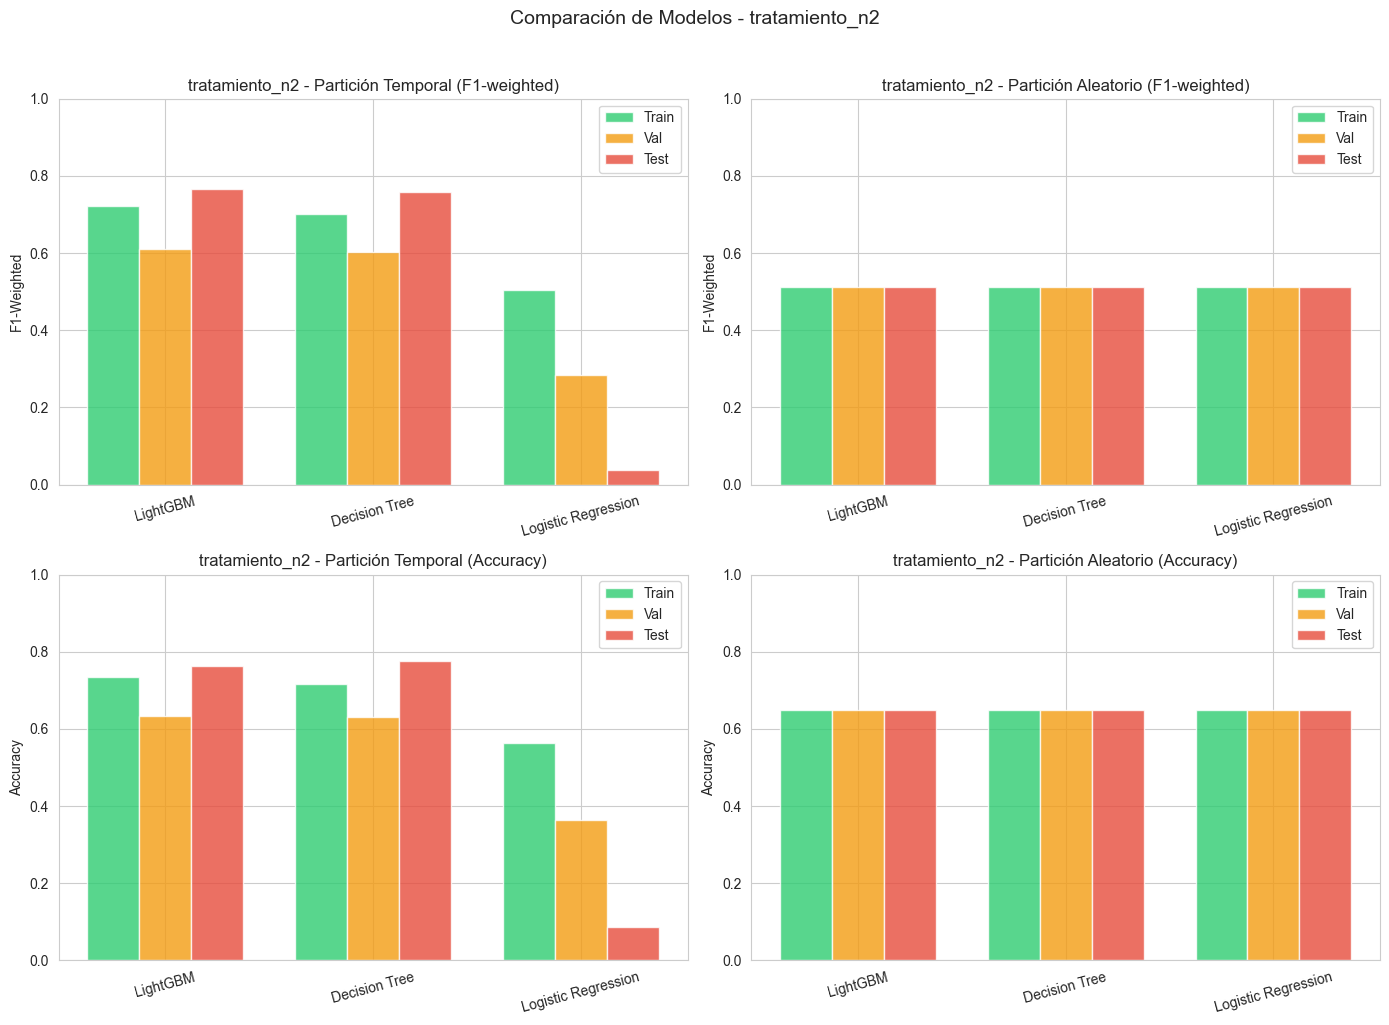

In [40]:
def plot_results_comparison_n2(results_ts, results_rd, target_name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Primera fila: F1-weighted
    for idx, (results, split_name) in enumerate([(results_ts, 'Temporal'), (results_rd, 'Aleatorio')]):
        models = [r['name'] for r in results]
        metric = 'f1_weighted'
        train_scores = [r['train'].get(metric, np.nan) for r in results]
        val_scores = [r['val'].get(metric, np.nan) for r in results]
        test_scores = [r['test'].get(metric, np.nan) for r in results]

        x = np.arange(len(models))
        width = 0.25
        ax = axes[idx // 2, idx % 2]
        for i, (scores, label, color) in enumerate([
            (train_scores, 'Train', '#2ecc71'),
            (val_scores, 'Val', '#f39c12'),
            (test_scores, 'Test', '#e74c3c')
        ]):
            ax.bar(x + i*width, scores, width, label=label, alpha=0.8, color=color)

        ax.set_xticks(x + width)
        ax.set_xticklabels(models, rotation=15)
        ax.set_ylabel('F1-Weighted')
        ax.set_title(f'{target_name} - Partición {split_name} (F1-weighted)')
        ax.legend()
        ax.set_ylim(0, 1)

    # Segunda fila: Accuracy
    for idx, (results, split_name) in enumerate([(results_ts, 'Temporal'), (results_rd, 'Aleatorio')]):
        models = [r['name'] for r in results]
        ax = axes[1, idx]

        train_acc = [r['train'].get('accuracy', np.nan) for r in results]
        val_acc = [r['val'].get('accuracy', np.nan) for r in results]
        test_acc = [r['test'].get('accuracy', np.nan) for r in results]

        x = np.arange(len(models))
        width = 0.25
        for i, (scores, label, color) in enumerate([
            (train_acc, 'Train', '#2ecc71'),
            (val_acc, 'Val', '#f39c12'),
            (test_acc, 'Test', '#e74c3c')
        ]):
            ax.bar(x + i*width, scores, width, label=label, alpha=0.8, color=color)

        ax.set_xticks(x + width)
        ax.set_xticklabels(models, rotation=15)
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{target_name} - Partición {split_name} (Accuracy)')
        ax.legend()
        ax.set_ylim(0, 1)

    plt.suptitle(f'Comparación de Modelos - {target_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_results_comparison_n2(results_n2_ts, results_n2_rd, 'tratamiento_n2')


In [41]:
def results_to_df_n2(results_ts, results_rd, target_name):
    rows = []
    for results, split in [(results_ts, 'Temporal'), (results_rd, 'Aleatorio')]:
        for r in results:
            for dataset in ['train', 'val', 'test']:
                row = {
                    'Target': target_name,
                    'Split': split,
                    'Model': r['name'],
                    'Dataset': dataset.capitalize()
                }
                for m in ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_macro', 'f1_weighted']:
                    row[m] = r[dataset].get(m, np.nan)
                rows.append(row)
    return pd.DataFrame(rows)

results_n2_df = results_to_df_n2(results_n2_ts, results_n2_rd, 'tratamiento_n2')
display(results_n2_df)


,Target,Split,Model,Dataset,accuracy,precision_weighted,recall_weighted,f1_macro,f1_weighted
0,tratamiento_n2,Temporal,LightGBM,Train,0.735269,0.733762,0.735269,0.535082,0.721637
1,tratamiento_n2,Temporal,LightGBM,Val,0.634431,0.622227,0.634431,0.347222,0.611535
2,tratamiento_n2,Temporal,LightGBM,Test,0.763321,0.839797,0.763321,0.209519,0.765025
3,tratamiento_n2,Temporal,Decision Tree,Train,0.717071,0.704971,0.717071,0.412163,0.700742
4,tratamiento_n2,Temporal,Decision Tree,Val,0.631068,0.622898,0.631068,0.323402,0.602010
5,tratamiento_n2,Temporal,Decision Tree,Test,0.774736,0.785997,0.774736,0.190900,0.757448
6,tratamiento_n2,Temporal,Logistic Regression,Train,0.562259,0.479913,0.562259,0.188667,0.503229
7,tratamiento_n2,Temporal,Logistic Regression,Val,0.364516,0.505178,0.364516,0.126913,0.283697
8,tratamiento_n2,Temporal,Logistic Regression,Test,0.087299,0.479309,0.087299,0.059910,0.036842
9,tratamiento_n2,Aleatorio,LightGBM,Train,0.649644,0.691307,0.649644,0.114846,0.511729


# 7. Cross-Validation con Folds (tratamiento_n2)

In [42]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Validación cruzada estratificada con 5 folds
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring_cv = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

cv_models = {
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=10, learning_rate=0.05,
                                   random_state=RANDOM_STATE, verbose=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=RANDOM_STATE),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])
}

X_all = base[feature_cols]
y_n2_all = base['tratamiento_n2_enc']

print('Ejecutando Cross-Validation (5 folds)...')
cv_results_n2 = []
for model_name, model in cv_models.items():
    print(f'  -> {model_name} ...')
    scores = cross_validate(model, X_all, y_n2_all, cv=cv, scoring=scoring_cv)
    for fold in range(N_FOLDS):
        row = {'Model': model_name, 'Fold': fold + 1}
        for metric in scoring_cv:
            row[metric] = scores[f'test_{metric}'][fold]
        cv_results_n2.append(row)

df_cv_n2 = pd.DataFrame(cv_results_n2)
print('\nMétricas por fold:')
display(df_cv_n2)

print('\nResumen promedio (media ± std):')
display(df_cv_n2.groupby('Model')[list(scoring_cv)].agg(['mean', 'std']))


Ejecutando Cross-Validation (5 folds)...
  -> LightGBM ...


  -> Decision Tree ...
  -> Logistic Regression ...

Métricas por fold:


,Model,Fold,accuracy,precision_weighted,recall_weighted,f1_macro,f1_weighted
0,LightGBM,1,0.765646,0.754642,0.765646,0.467096,0.748700
1,LightGBM,2,0.766626,0.755149,0.766626,0.470431,0.749898
2,LightGBM,3,0.766780,0.755913,0.766780,0.485461,0.750327
3,LightGBM,4,0.770527,0.762435,0.770527,0.477763,0.753761
4,LightGBM,5,0.768375,0.756502,0.768375,0.479826,0.751982
5,Decision Tree,1,0.751415,0.737054,0.751415,0.388442,0.731443
6,Decision Tree,2,0.750396,0.730670,0.750396,0.389350,0.731209
7,Decision Tree,3,0.751155,0.737232,0.751155,0.389975,0.731366
8,Decision Tree,4,0.753942,0.733102,0.753942,0.400454,0.735247
9,Decision Tree,5,0.752866,0.733283,0.752866,0.393261,0.733101



Resumen promedio (media ± std):


accuracy           precision_weighted            \
                         mean       std               mean       std   
Model                                                                  
Decision Tree        0.751955  0.001426           0.734268  0.002821   
LightGBM             0.767591  0.001911           0.756928  0.003160   
Logistic Regression  0.656151  0.000654           0.565504  0.001093   

                    recall_weighted            f1_macro           f1_weighted  \
                               mean       std      mean       std        mean   
Model                                                                           
Decision Tree              0.751955  0.001426  0.392297  0.004909    0.732473   
LightGBM                   0.767591  0.001911  0.476116  0.007374    0.750934   
Logistic Regression        0.656151  0.000654  0.186182  0.000676    0.593382   

                               
                          std  
Model                          
Decision Tree        0.001730  
LightGBM             0.001970  
Logistic Regression  0.000796

## 7.1 Boxplots de Métricas (Cross-Validation)

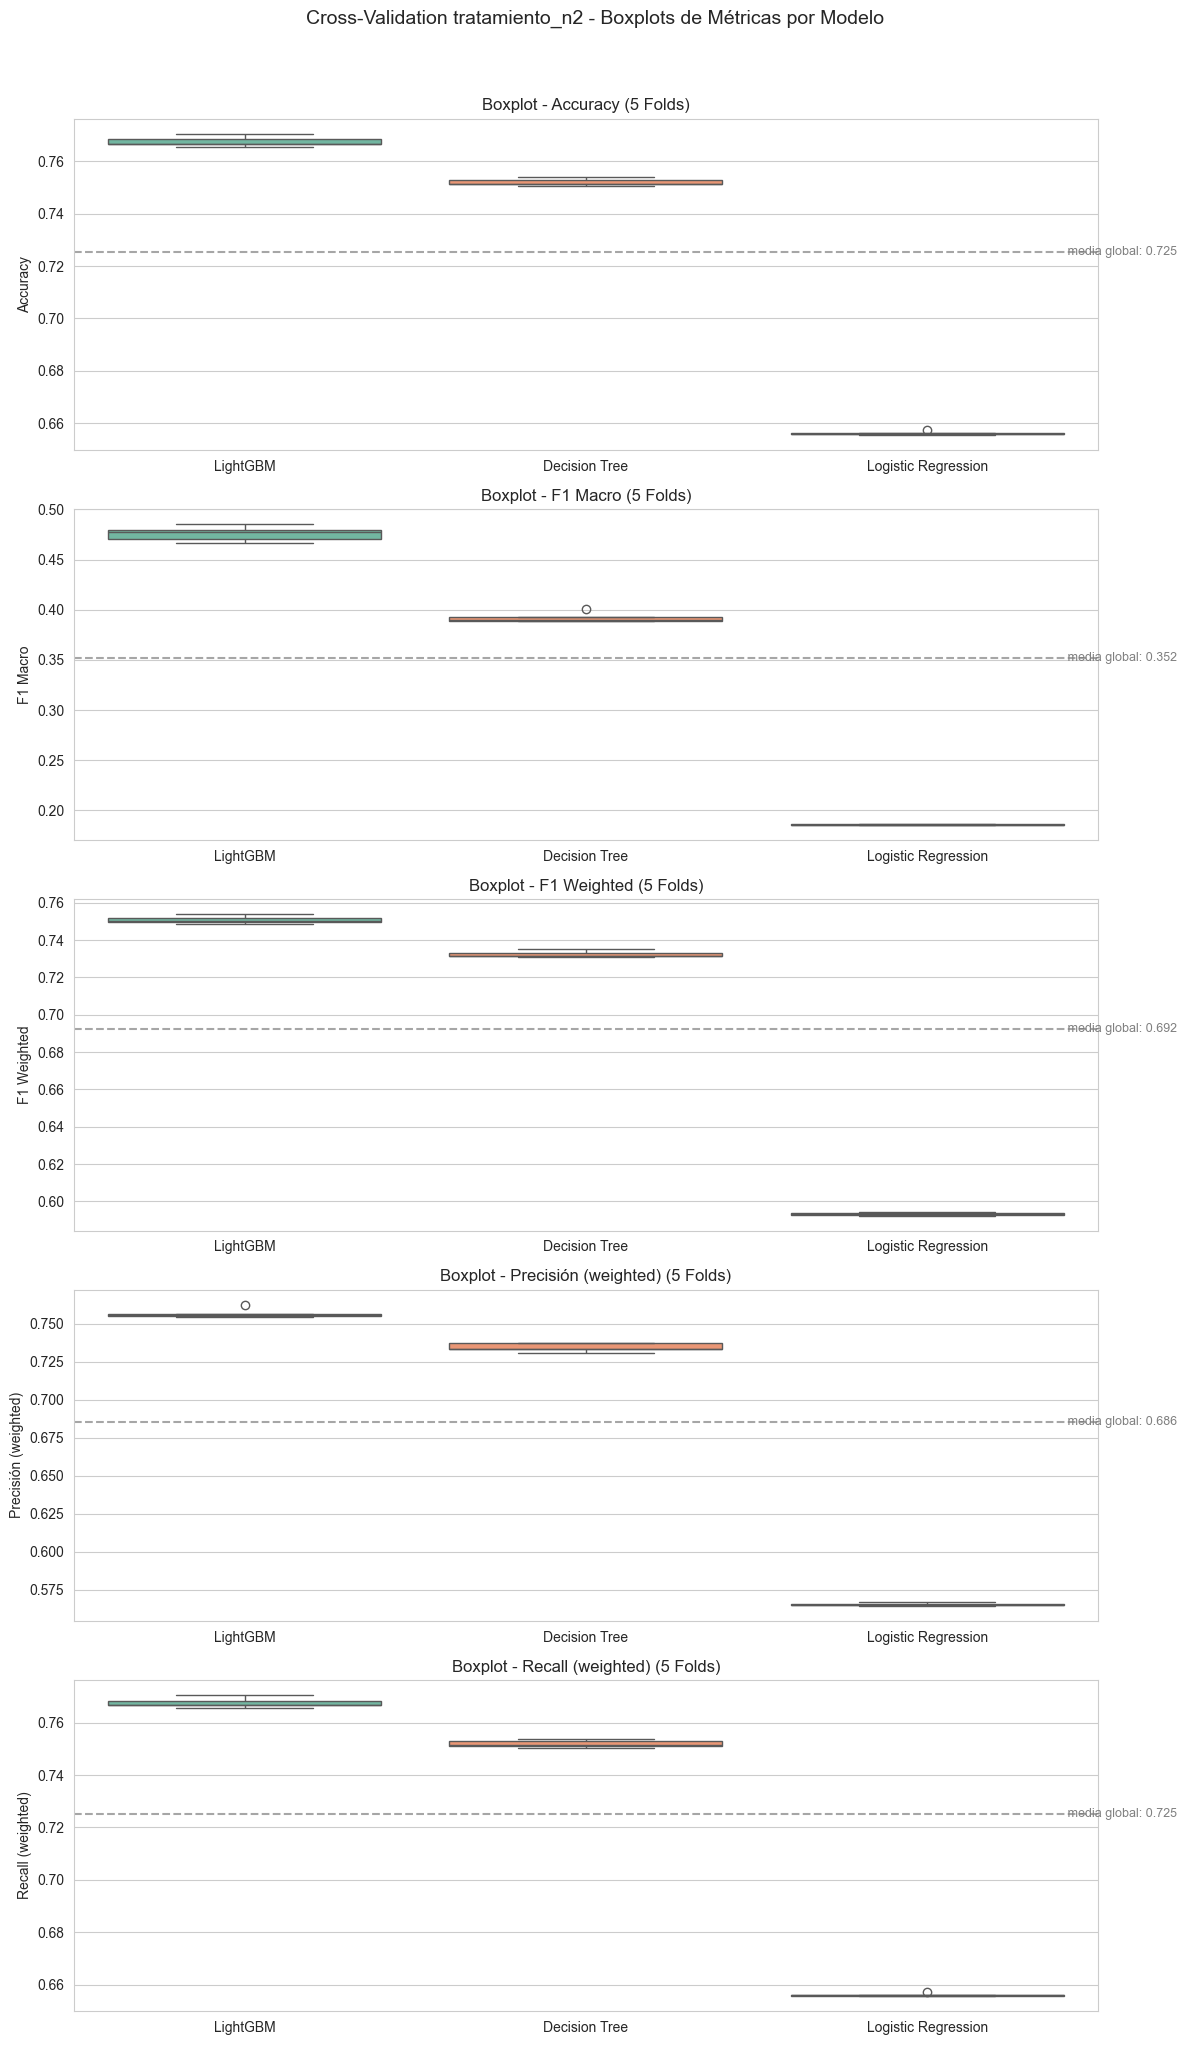

In [43]:
metrics_cv = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_weighted', 'recall_weighted']
metric_labels = {
    'accuracy': 'Accuracy',
    'f1_macro': 'F1 Macro',
    'f1_weighted': 'F1 Weighted',
    'precision_weighted': 'Precisión (weighted)',
    'recall_weighted': 'Recall (weighted)'
}

fig, axes = plt.subplots(len(metrics_cv), 1, figsize=(12, 4 * len(metrics_cv)))
for i, metric in enumerate(metrics_cv):
    sns.boxplot(data=df_cv_n2, x='Model', y=metric, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Boxplot - {metric_labels[metric]} (5 Folds)', fontsize=12)
    axes[i].set_ylabel(metric_labels[metric])
    axes[i].set_xlabel('')
    # Marcar la media global como referencia
    global_mean = df_cv_n2[metric].mean()
    axes[i].axhline(global_mean, color='gray', linestyle='--', alpha=0.7)
    axes[i].text(2.4, global_mean, f' media global: {global_mean:.3f}',
                 fontsize=9, va='center', color='gray')
plt.suptitle('Cross-Validation tratamiento_n2 - Boxplots de Métricas por Modelo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 7.2 Heatmap de Métricas (en negrita)

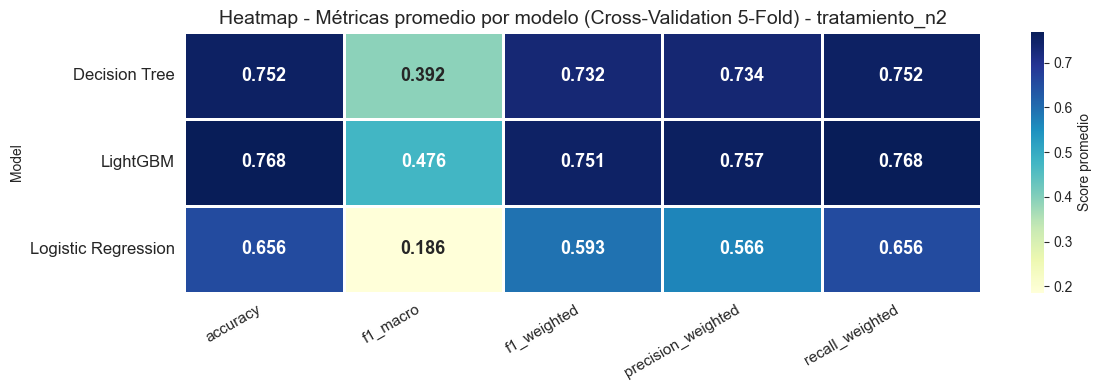

Desviación estándar por modelo:


,accuracy,f1_macro,f1_weighted,precision_weighted,recall_weighted
Model,,,,,
Decision Tree,0.001,0.005,0.002,0.003,0.001
LightGBM,0.002,0.007,0.002,0.003,0.002
Logistic Regression,0.001,0.001,0.001,0.001,0.001


In [44]:
# Media de cada métrica por modelo
cv_mean_n2 = df_cv_n2.groupby('Model')[metrics_cv].mean()
cv_std_n2 = df_cv_n2.groupby('Model')[metrics_cv].std()

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cv_mean_n2, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Score promedio'},
            annot_kws={'fontsize': 13, 'fontweight': 'bold'}, ax=ax)
ax.set_title('Heatmap - Métricas promedio por modelo (Cross-Validation 5-Fold) - tratamiento_n2', fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

# Añadir std como texto (tamaño 12, negrita)
print('Desviación estándar por modelo:')
display(cv_std_n2.round(3))
